In [ ]:
%run scripts/verify_environment.py

verify_environment()

In [2]:
from datetime import datetime
from getpass import getpass

rdm_url = 'https://rdm.example.com/'
idp_name_1 = 'GakuNin RDM IdP'
idp_username_1 = None
idp_password_1 = None
folder_1 = None
folder_2 = None
googledrive_folder_1 = None
googledrive_folder_2 = None
rdm_project_prefix = 'TEST-DROPBOX-{}'.format(datetime.now().strftime('%Y%m%d-%H%M%S'))
target_storage_name = 'Dropbox'
target_storage_id = 'dropbox'
external_config_path = True
default_result_path = None
close_on_fail = False
transition_timeout = 30000

In [3]:
import yaml
if external_config_path:
    config_path = input(prompt='設定ファイルのパス:')
    with open(config_path) as f:
        for k, v in yaml.load(f.read(), Loader=yaml.SafeLoader).items():
            locals()[k] = v

設定ファイルのパス: /tmp/tmpk9o87ox_/.config.yaml


In [4]:
if idp_username_1 is None:
    idp_username_1 = input(prompt=f'Username for {idp_name_1}')
if idp_password_1 is None:
    idp_password_1 = getpass(prompt=f'Password for {idp_username_1}@{idp_name_1}')
(len(idp_username_1), len(idp_password_1))

(16, 20)

In [5]:
if folder_1 is None:
    folder_1 = input(prompt='Storage Folder #1')
if folder_2 is None:
    folder_2 = input(prompt='Storage Folder #2')
(folder_1, folder_2)

('RDM1', 'RDM2')

In [6]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/tmp/tmp5ydnqf8n'

# GakuNinRDM 総合テスト [拡張ストレージ]

- サブシステム名: ログイン
- ページ/アドオン: トップページ
- 機能分類: アカウント制御確認
- シナリオ名: *
- 用意するテストデータ: URL一覧、アカウント(既存ユーザー1: GRDM)

## ウェブブラウザの新規プライベートウィンドウでGRDMトップページを表示する

GRDMトップページが表示されること

In [7]:
import importlib
import pandas as pd

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path)

('20250528-032825', '/tmp/tmpx2w1zwwp')

Start epoch: 1748402905.8606365 seconds


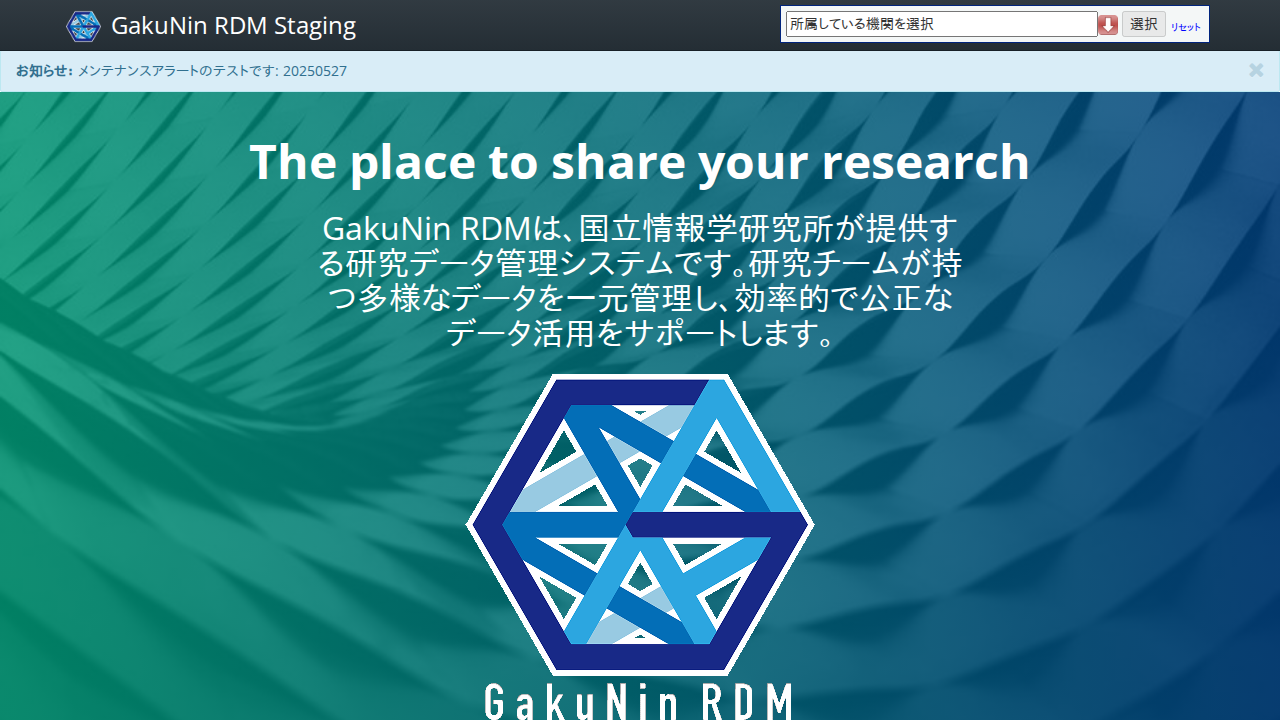

In [8]:
import time

async def _step(page):
    await page.goto(rdm_url)

    # 同意する ボタンが現れるまで待つ
    await expect(page.locator('//button[text() = "同意する"]')).to_be_visible(timeout=transition_timeout)

    # 同意する をクリック
    await page.locator('//button[text() = "同意する"]').click()

    # 同意する が表示されなくなったことを確認
    await expect(page.locator('//button[text() = "同意する"]')).to_have_count(0, timeout=500)

await run_pw(_step)

## ログイン情報を用いてGakuNin RDMにログインする

(IdPに関するログイン情報が与えられた場合、)
GakuNin Embeded DSのプルダウンを展開し、IdPリストから指定されたIdPを選択する。その後、アカウントのID/Passwordを入力して「Login」ボタンを押下する。

(IdPが指定されていない場合、)
CASのログイン操作を実施する。

Start epoch: 1748402908.090917 seconds


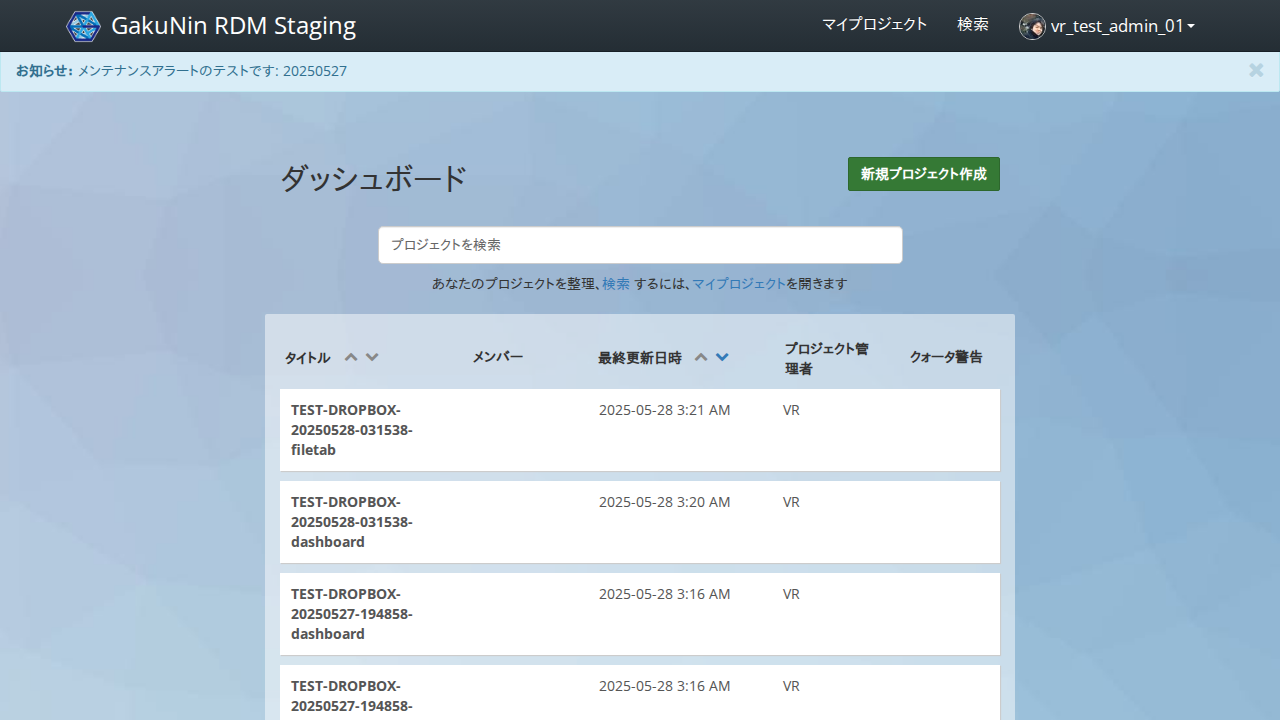

In [9]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await scripts.grdm.login(
        page, idp_name_1, idp_username_1, idp_password_1, transition_timeout=transition_timeout
    )

    # GRDMのボタンが表示されることを確認
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## ユーザーメニューから「設定」を選択する


Start epoch: 1748402917.004433 seconds


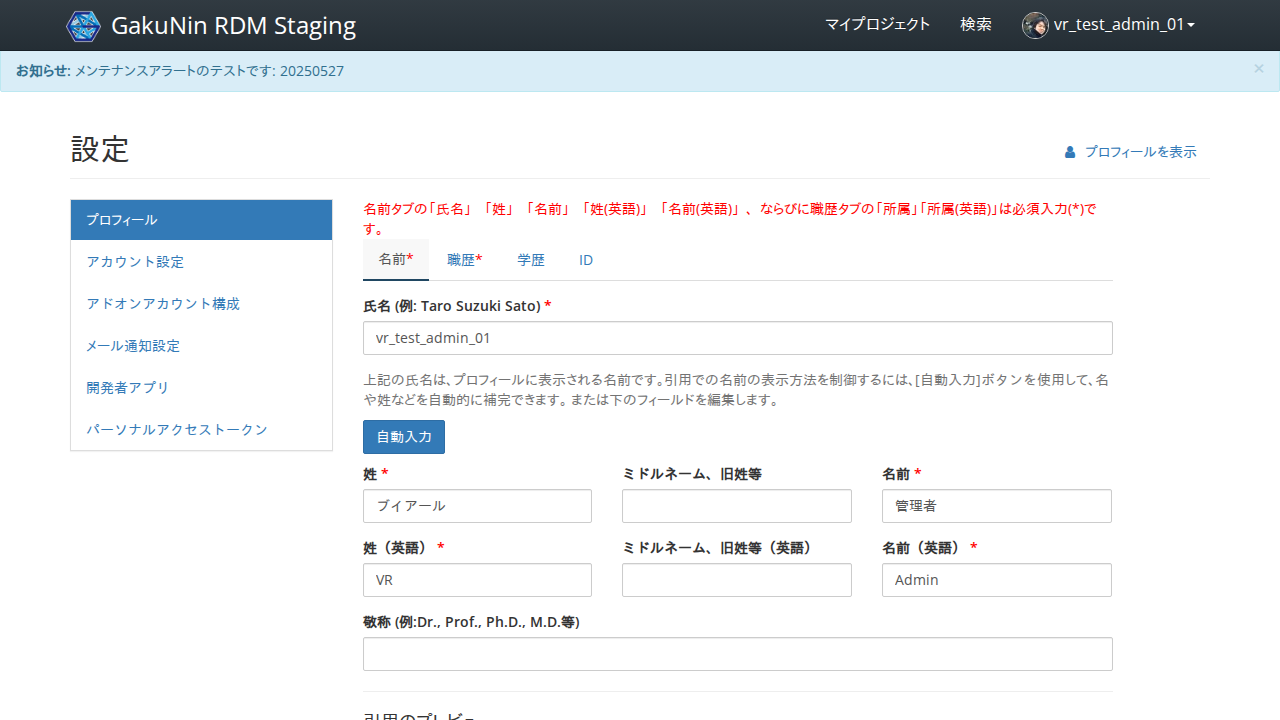

In [10]:
async def _step(page):
    await page.locator(f'//div[@class = "nav-profile-name"]').click()
    await page.locator('//*[@data-analytics-name="Settings"]').click()

    await expect(page.locator('//*[text() = "アドオンアカウント構成"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「アドオンアカウント構成」を選択する


Start epoch: 1748402917.993672 seconds


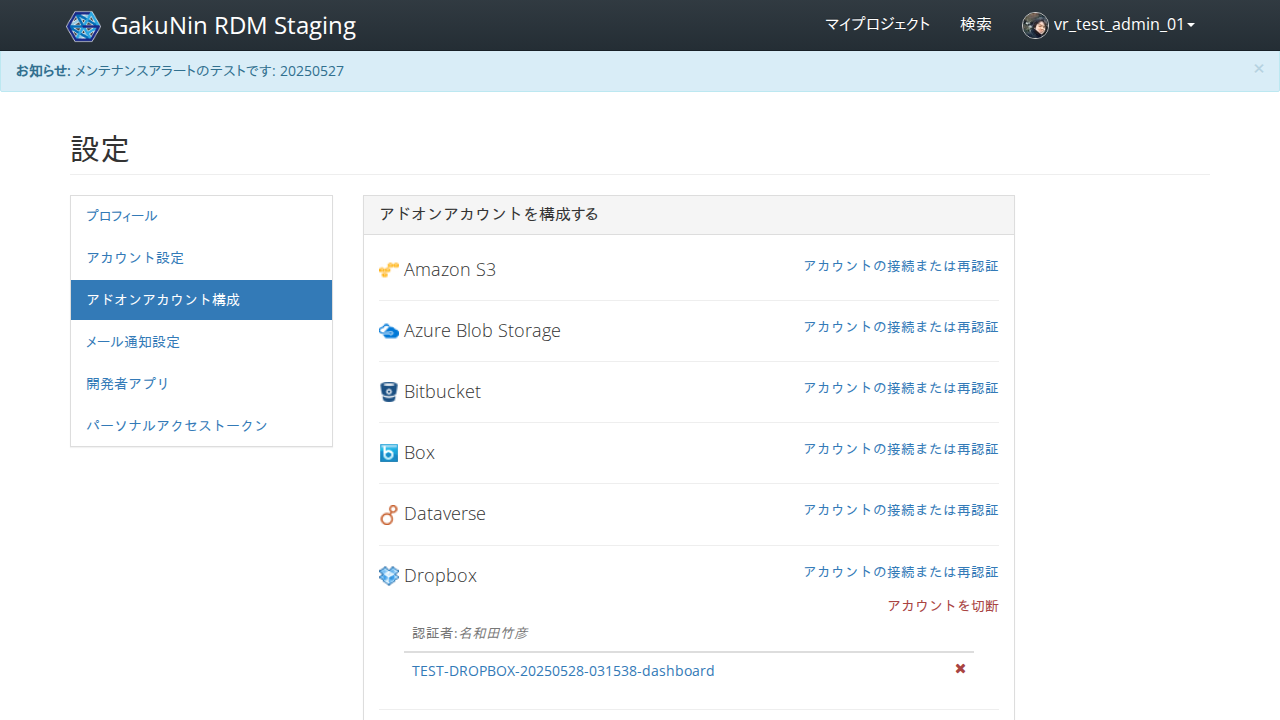

In [11]:
import traceback

has_connections = False

async def _step(page):
    global has_connections
    await page.locator('//*[text() = "アドオンアカウント構成"]').click()
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../*[text() = "{target_storage_name}"]')).to_be_visible(timeout=transition_timeout)
    # 30秒以内に「アカウントを切断」が1つ以上表示されるかを確認
    try:
        await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"][1]')).to_be_visible(timeout=30000)
        has_connections = True
    except:
        print('Ignored')
        traceback.print_exc()
        has_connections = False

await run_pw(_step)

## (「アカウントを切断」が対象ストレージに表示されている場合)すべての「アカウントを切断」をクリックし、「Disconnect」をクリックする



Start epoch: 1748402920.1989198 seconds
Disconnecting...
Ignored


Traceback (most recent call last):
  File "/tmp/ipykernel_10542/4234603193.py", line 18, in _step
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"][1]')).to_be_visible(timeout=30000)
  File "/opt/conda/lib/python3.12/site-packages/playwright/async_api/_generated.py", line 20190, in to_be_visible
    await self._impl_obj.to_be_visible(visible=visible, timeout=timeout)
  File "/opt/conda/lib/python3.12/site-packages/playwright/_impl/_assertions.py", line 716, in to_be_visible
    await self._expect_impl(
  File "/opt/conda/lib/python3.12/site-packages/playwright/_impl/_assertions.py", line 74, in _expect_impl
    raise AssertionError(
AssertionError: Locator expected to be visible
Actual value: <element(s) not found> 
Call log:
  - LocatorAssertions.to_be_visible with timeout 30000ms
  - waiting for locator("//*[@src=\"/static/addons/dropbox/comicon.png\"]/../..//*[text() = \"アカウントを切断\"][1]")



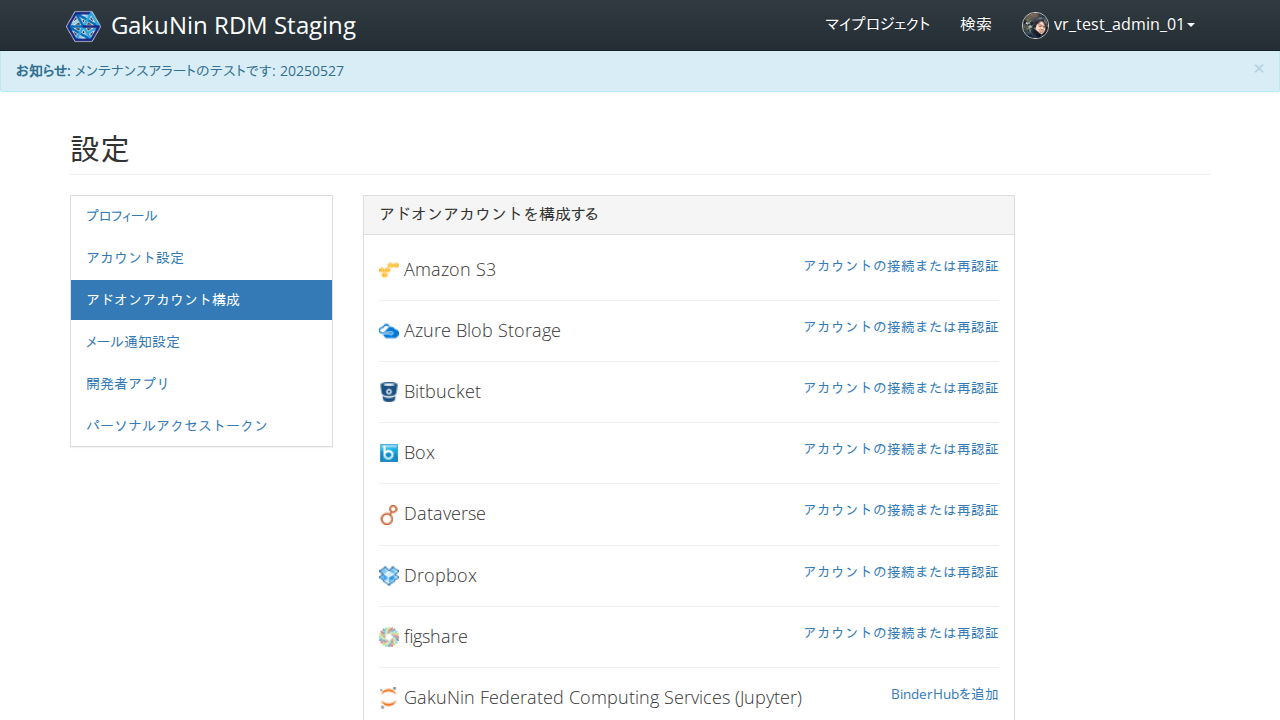

In [12]:
async def _step(page):
    if not has_connections:
        return
    try:
        await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"][1]')).to_be_visible(timeout=30000)
    except:
        print('Ignored')
        traceback.print_exc()
        return
    while True:
        print('Disconnecting...')
        await page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"][1]').click()
        await page.locator('.bootbox-confirm .btn-danger').click()
        # 30秒以内に「アカウントを切断」が表示されれば繰り返し
        try:
            # 前のものが消えるまで待つ...
            time.sleep(3)
            await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"][1]')).to_be_visible(timeout=30000)
        except:
            print('Ignored')
            traceback.print_exc()
            break
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"]')).to_have_count(0, timeout=transition_timeout)

await run_pw(_step)

## 左上 GakuNin RDMロゴをクリックする

Start epoch: 1748402954.3408282 seconds


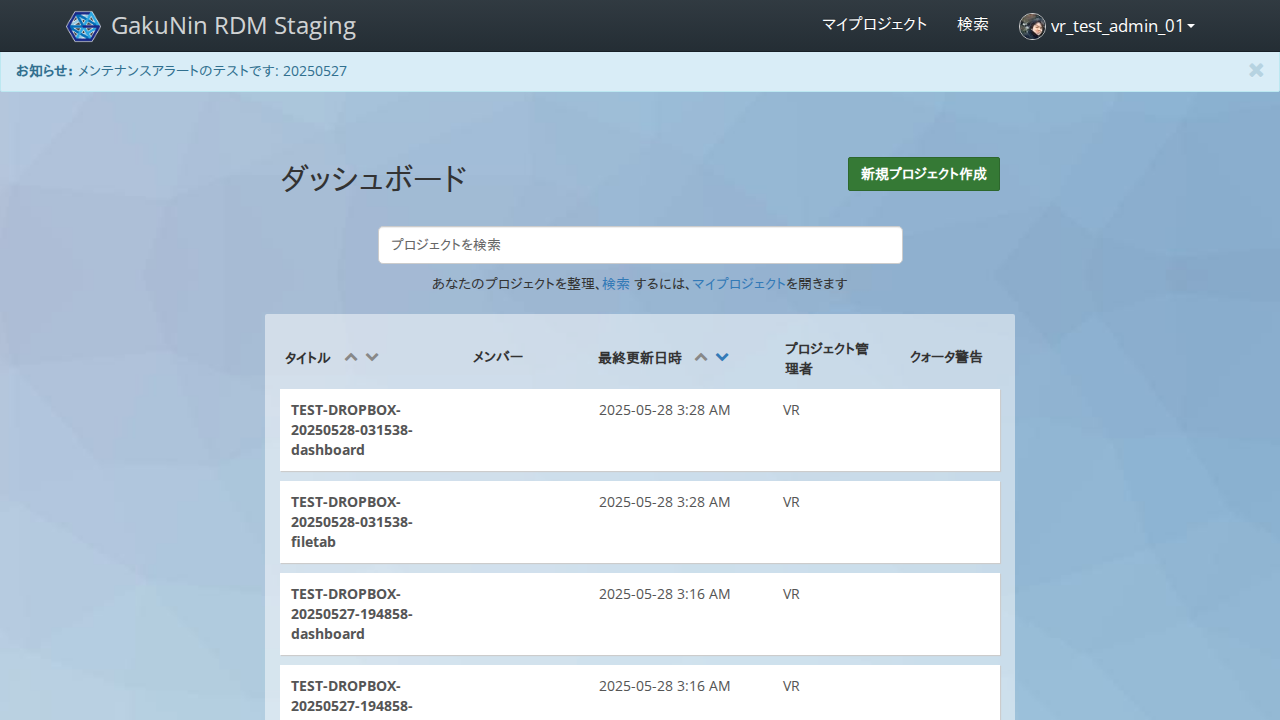

In [13]:
async def _step(page):
    await page.locator('//*[contains(@class, "service-name")]//a').click()
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「TEST-(ストレージID)-YYYYMMDD-HHMMSS-dashboard」プロジェクトを作成する

Start epoch: 1748402956.633895 seconds


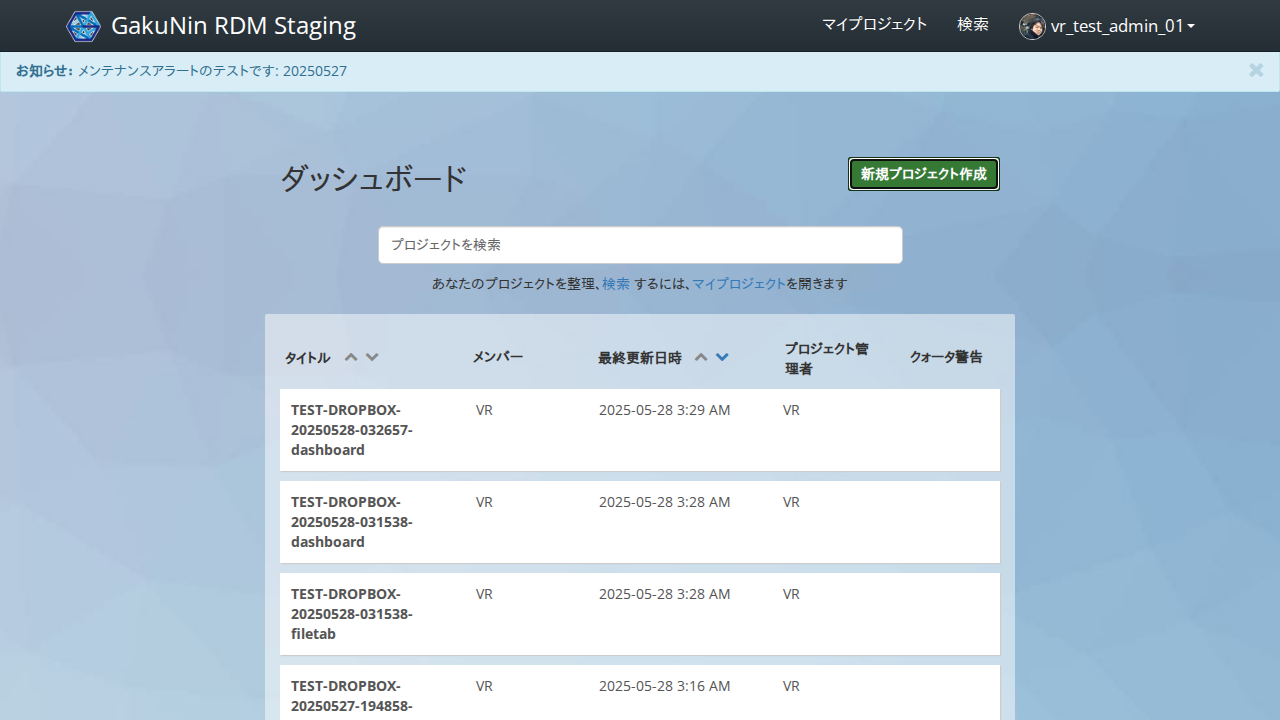

In [14]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1)

    await scripts.grdm.ensure_project_exists(page, f'{rdm_project_prefix}-dashboard', transition_timeout=transition_timeout)
        
await run_pw(_step)

## ダッシュボードのプロジェクト一覧から作成したプロジェクトをクリックする

Start epoch: 1748402965.7993522 seconds


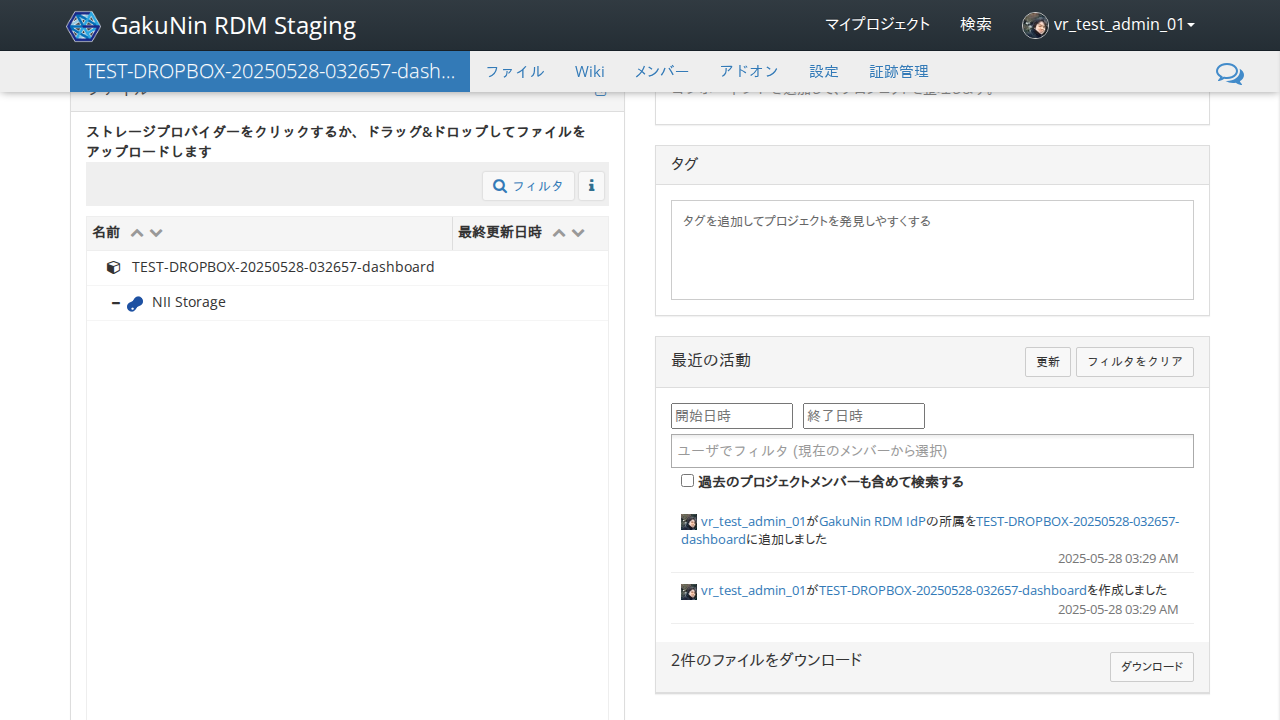

In [15]:
async def _step(page):
    await page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_prefix}-dashboard"]').click()        

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, 'NII Storage')).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

Start epoch: 1748402970.0156298 seconds


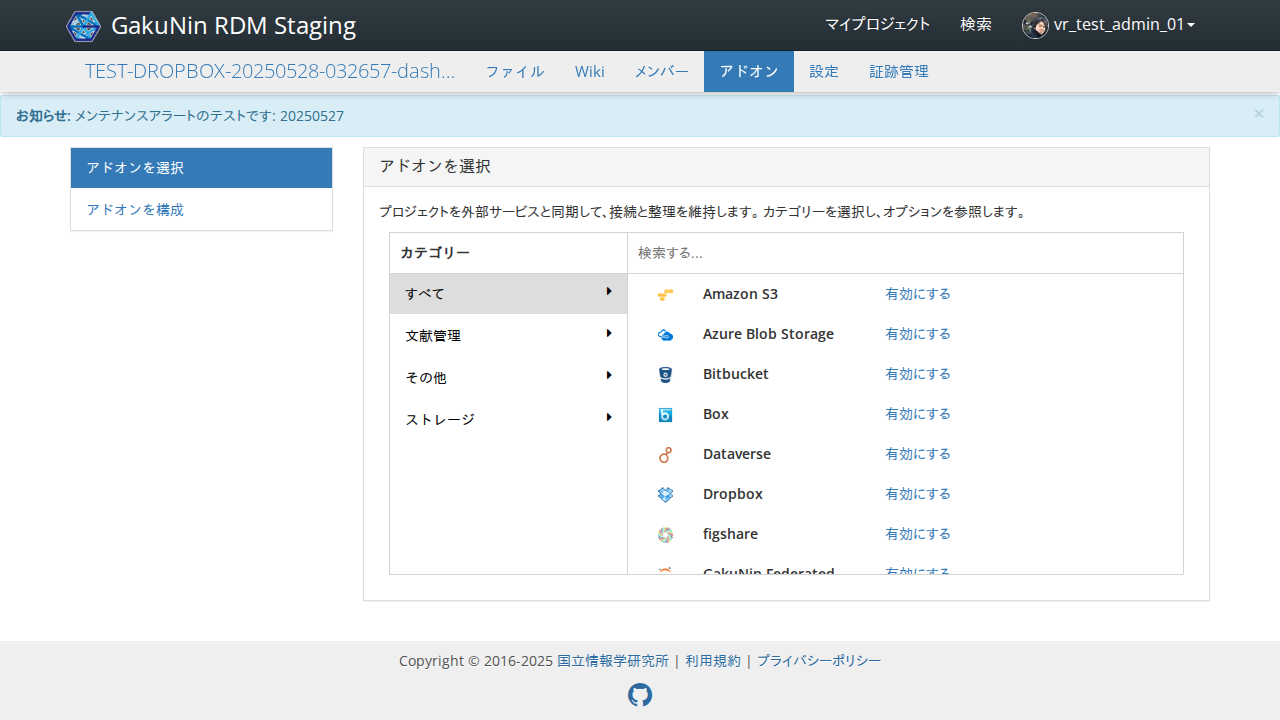

In [16]:
addon_name = target_storage_name

async def _step(page):
    await page.locator('//a[text() = "アドオン"]').click()

    await expect(page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「アドオンを選択」のパネル内対象ストレージの行の「有効にする」をクリックする

Start epoch: 1748402972.6303675 seconds


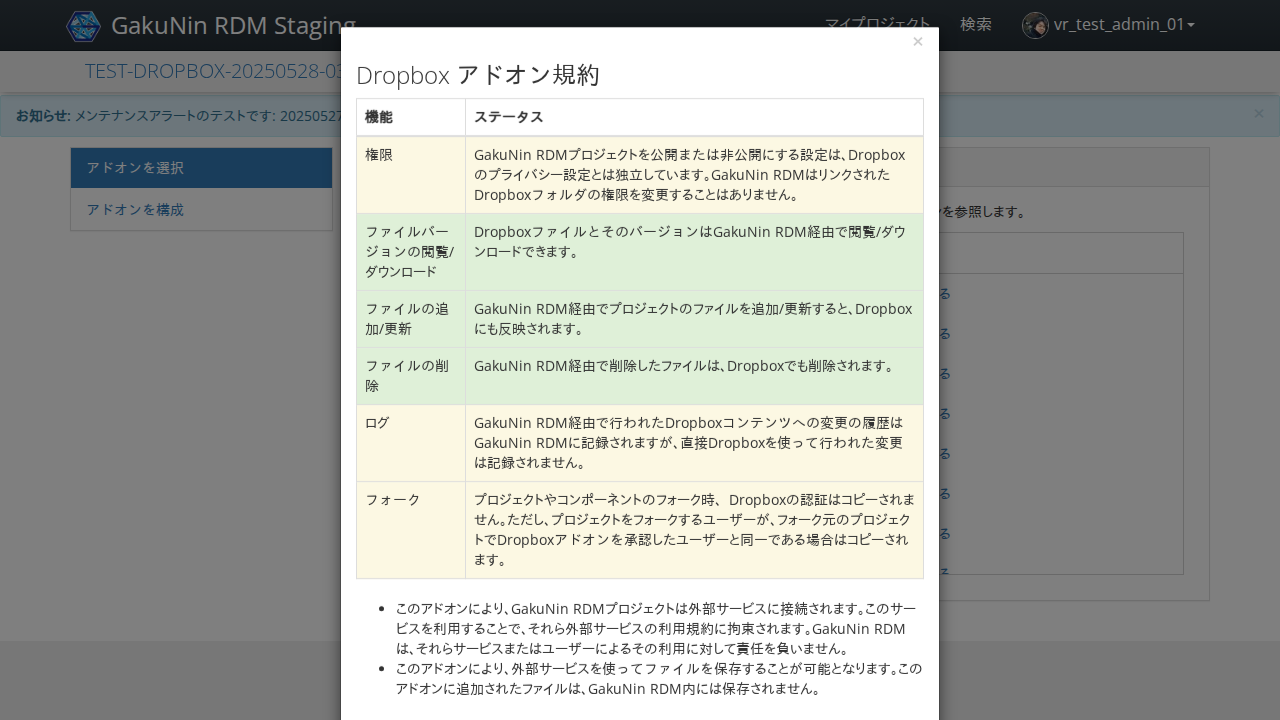

In [17]:
async def _step(page):
    await page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]').click()
    
    await expect(page.locator(f'//button[@data-bb-handler = "confirm"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「確認」をクリックする

Start epoch: 1748402973.2433407 seconds


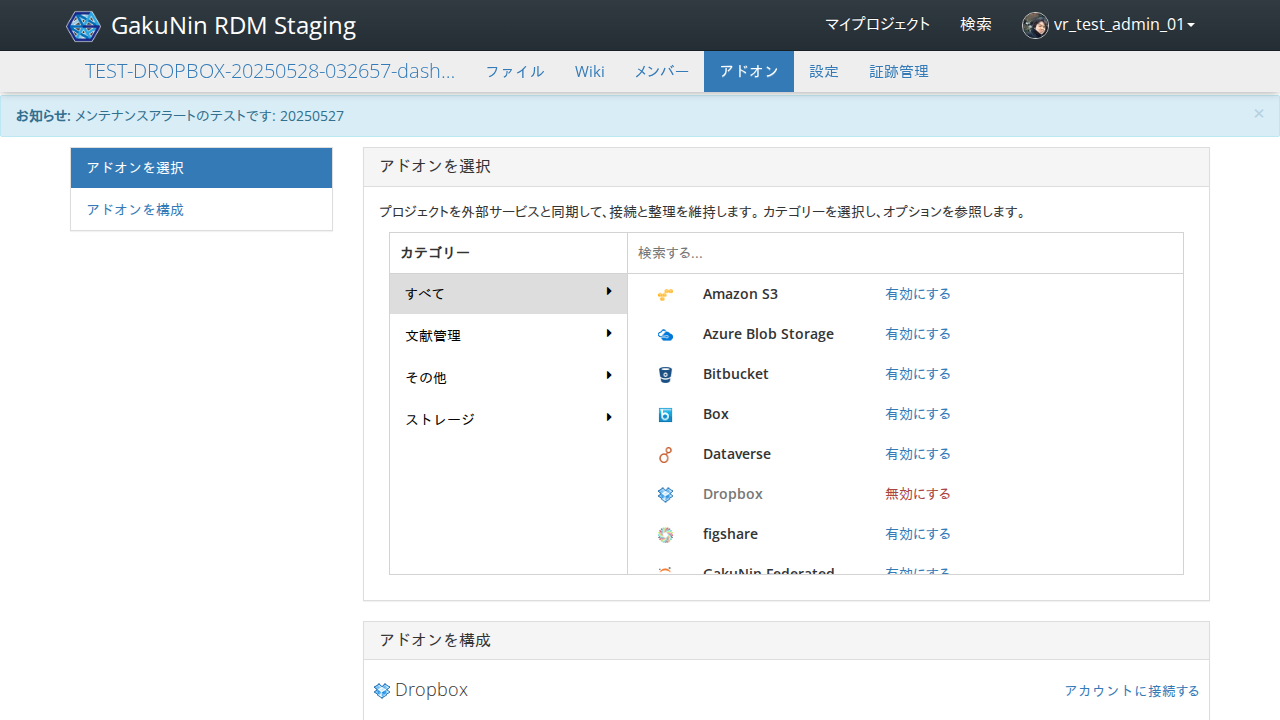

In [18]:
async def _step(page):
    await page.locator(f'//button[@data-bb-handler = "confirm"]').click()

    if target_storage_id == 'googledrive':
        await expect(page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(@class, "addon-auth")]')).to_be_visible(timeout=10000)
    else:
        await expect(page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "アカウントに接続する")]')).to_be_visible(timeout=10000)

await run_pw(_step)

## 「アカウントに接続する」(Google Driveの場合は「Sign in with Google」)リンクをクリックする

ここからは自動操作できないので、以下のセルの指示に従い、作業を実施する。

1. 指定されたURLをシークレットウィンドウで開く
2. IdPアカウント1でログインする
1. 「アカウントに接続する」(Google Driveの場合は「Sign in with Google」)リンクをクリックする
2. ストレージアカウント1で認証する
1. 1.で開いたシークレットウィンドウを閉じる

In [19]:
target_url = None
async def _step(page):
    global target_url
    target_url = page.url
await run_pw(_step)
print(target_url)

confirmed = input(prompt='上のURLを開き、セルに指示された作業を実施してください。完了したら、 finished と入力してください。')
assert confirmed.strip().lower() == 'finished'

Start epoch: 1748403083.9539268 seconds


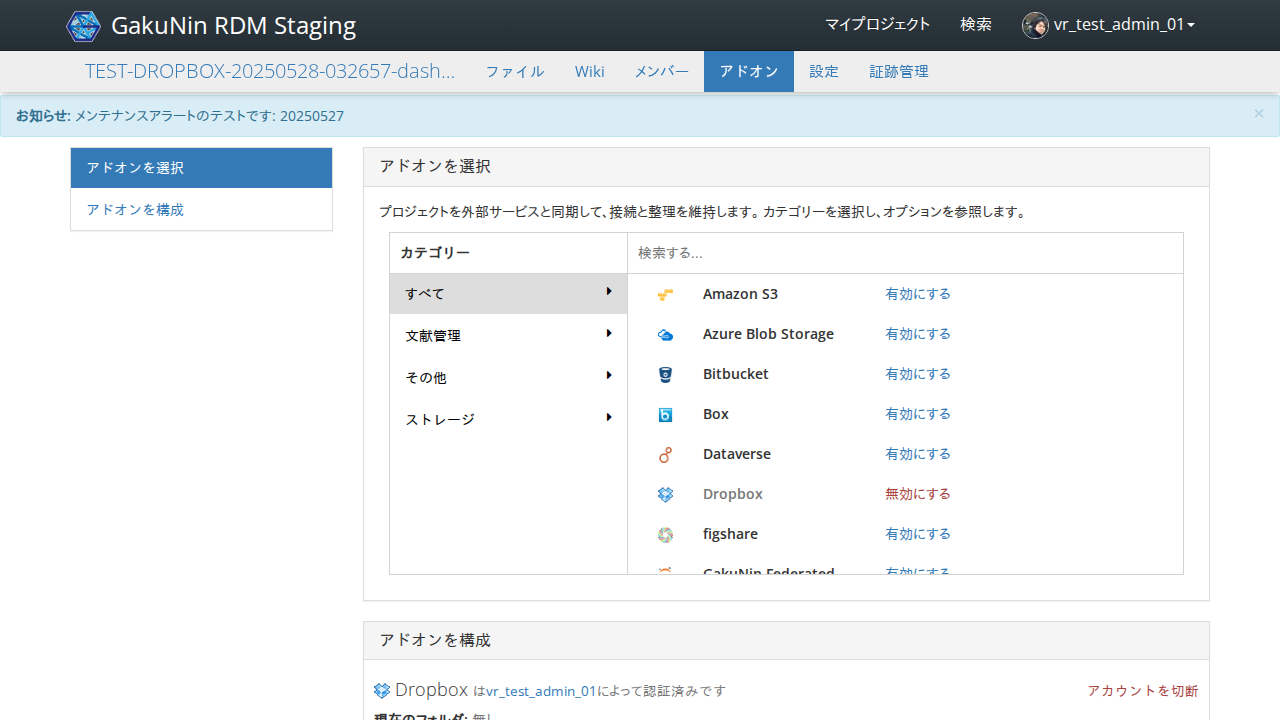

In [20]:
async def _step(page):
    await page.reload()
    
    await expect(page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "変更"]')).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)

## 「変更」をクリックする

Start epoch: 1748403088.6923194 seconds


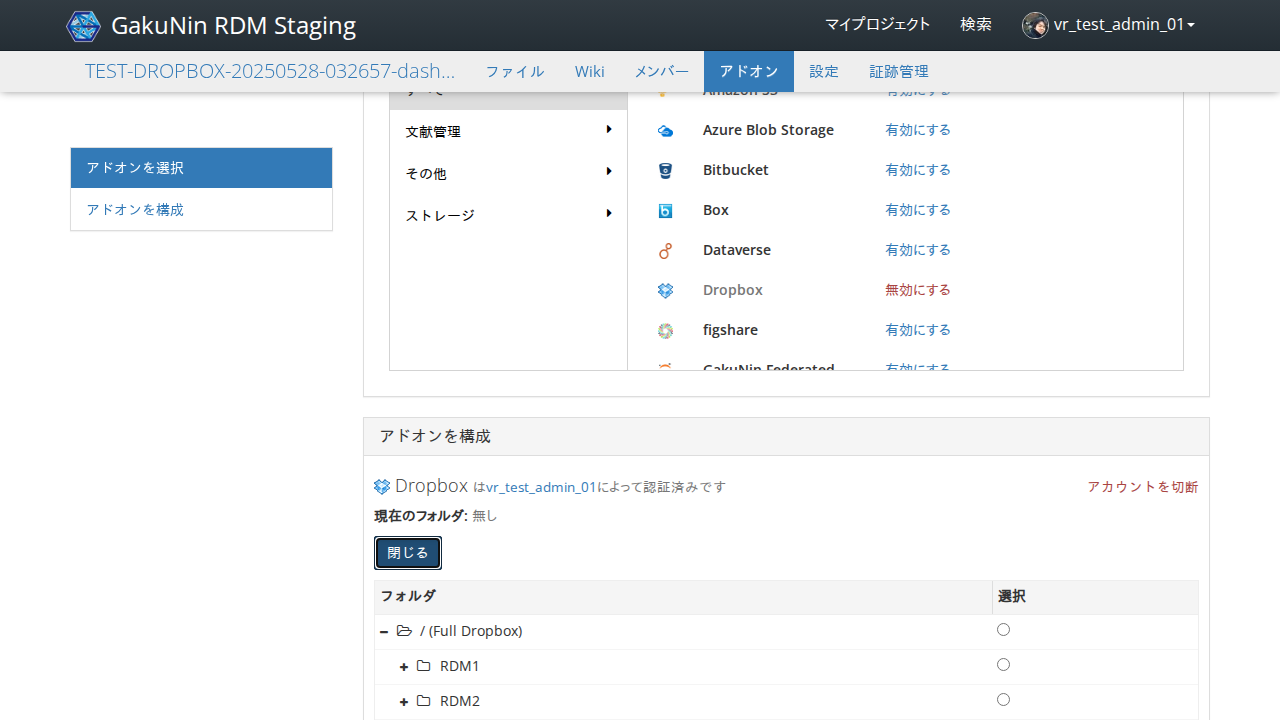

In [21]:
async def _step(page):
    await page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "変更"]').click()
    await expect(page.locator(f'//span[text() = "{folder_1}"]/../../..//input[@type = "radio"]')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)

## 指定されたフォルダを選択する

Start epoch: 1748403090.7744715 seconds


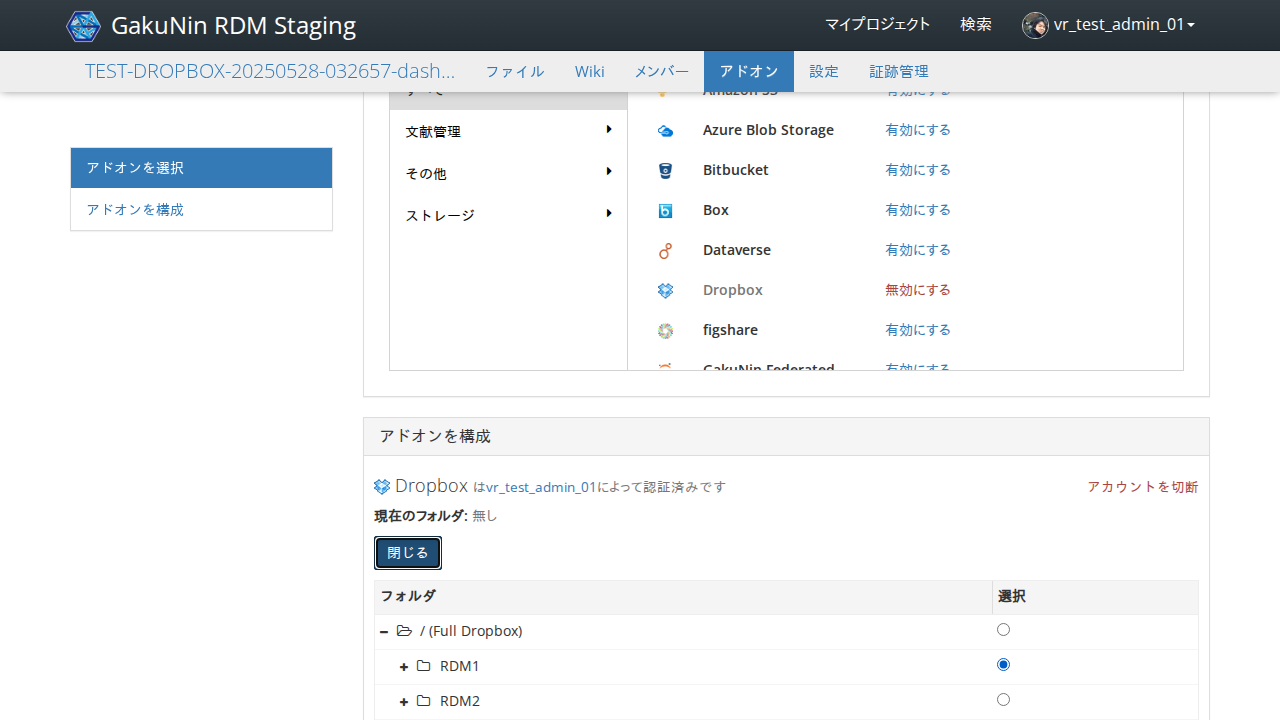

In [22]:
async def _step(page):
    await page.locator(f'//span[text() = "{folder_1}"]/../../..//input[@type = "radio"]').click()

await run_pw(_step)

## 「保存」をクリックする

Start epoch: 1748403090.9497888 seconds


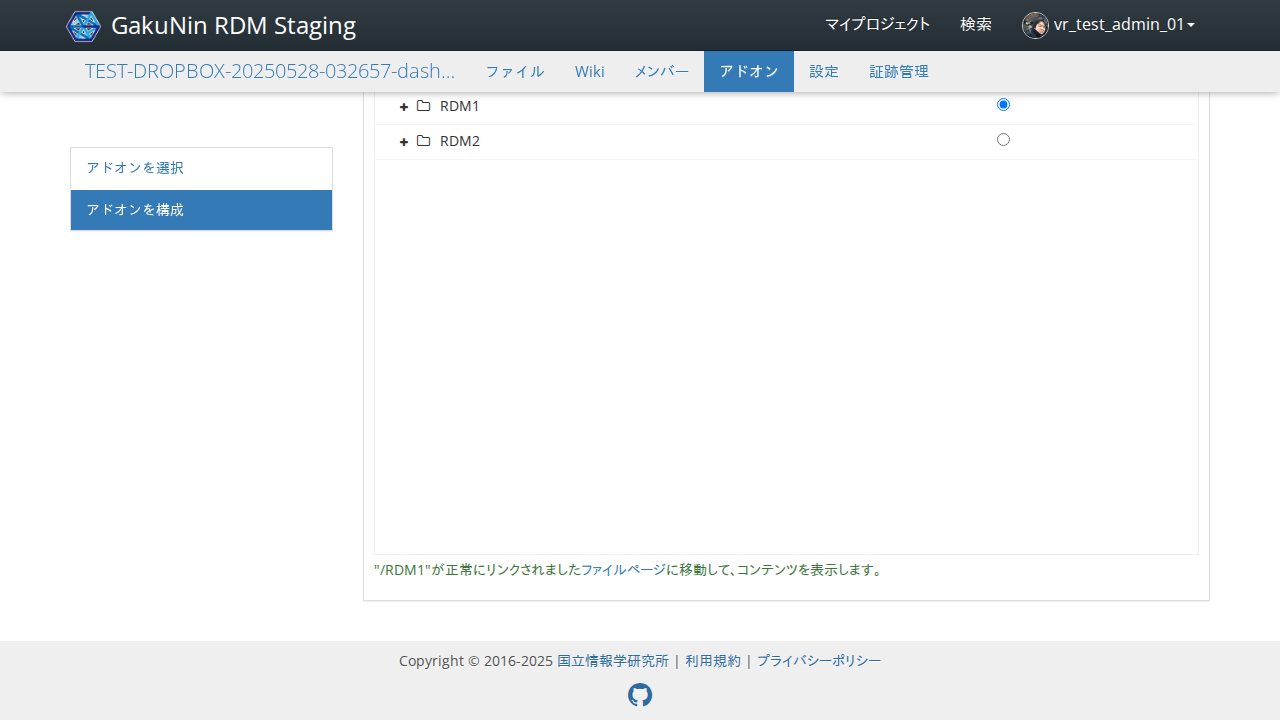

In [23]:
async def _step(page):
    # ここでdelayを入れないと 正常にリンクされました メッセージが表示されない(設定自体はなされるよう)
    time.sleep(1)
    await page.locator(f'//*[@class = "{target_storage_id}-confirm-selection"]//input[@value = "保存"]').click()
    await expect(page.locator(f'//*[@id = "{target_storage_id}Scope"]/*[contains(@class, "help-block")]//*[contains(text(), "正常にリンクされました")]')).to_be_visible(timeout=30000)

await run_pw(_step)

## 「ファイルページ」リンクをクリックする

Start epoch: 1748403092.5146909 seconds


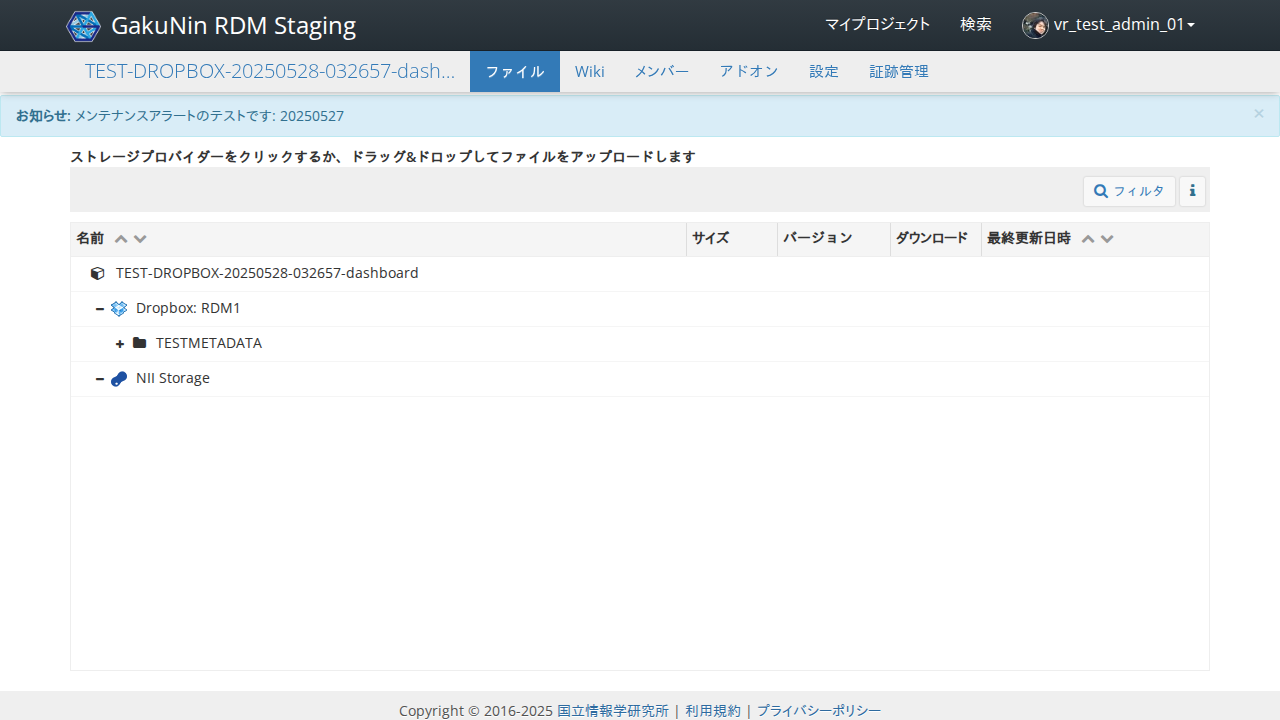

In [24]:
# import scripts.grdm
# importlib.reload(scripts.grdm)

async def _step(page):
    await page.get_by_role("link", name="ファイルページ").click()

    # ストレージが表示されること
    await expect(grdm.get_select_expanded_storage_title_locator(page, target_storage_name)).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await expect(page.locator('//h3[text()="最近の活動"]')).not_to_be_visible()

await run_pw(_step)

## 左上 GakuNin RDMロゴをクリックする

Start epoch: 1748403096.3781013 seconds


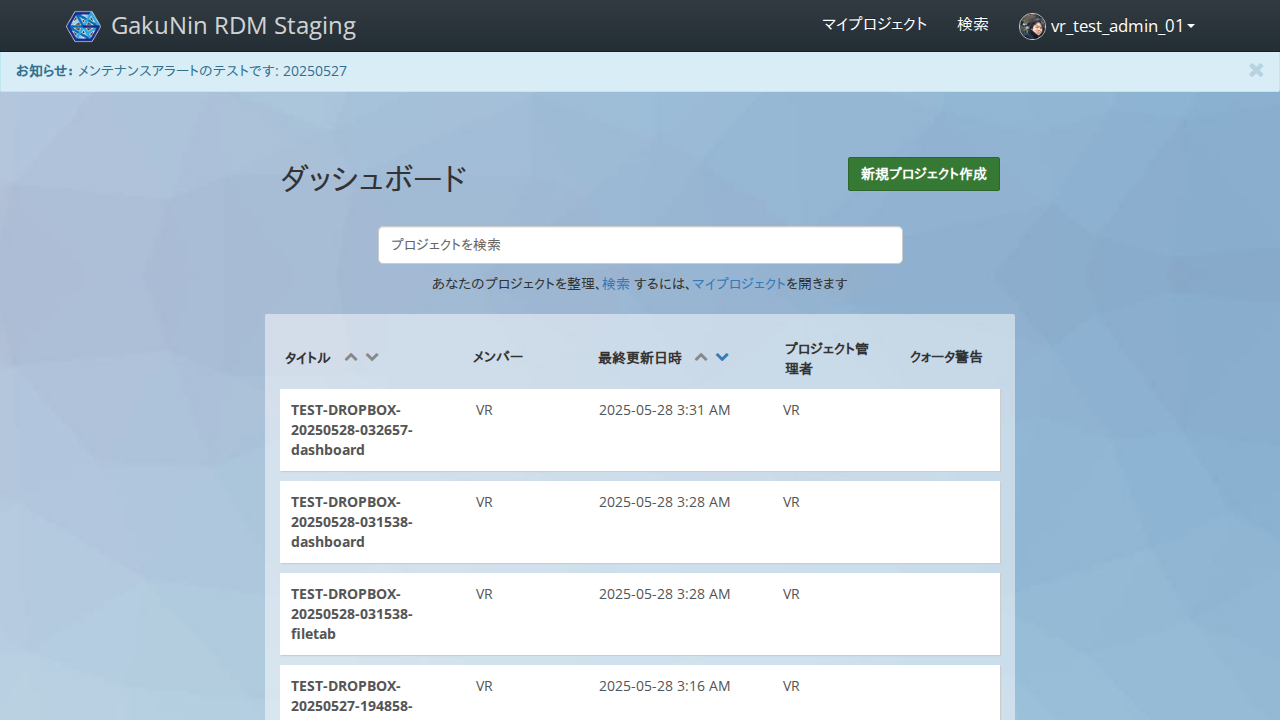

In [25]:
async def _step(page):
    await page.locator('//*[contains(@class, "service-name")]//a').click()
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「TEST-(ストレージID)-YYYYMMDD-HHMMSS-filetab」プロジェクトを作成する

Start epoch: 1748403098.8099122 seconds


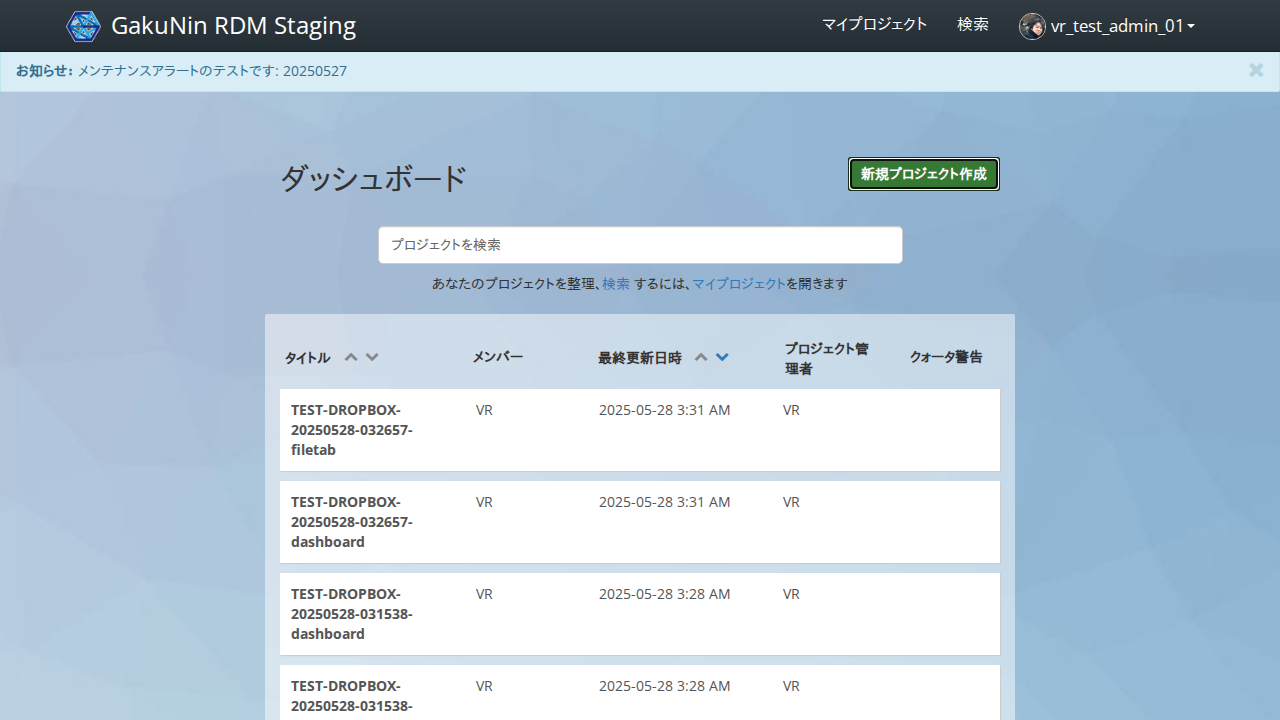

In [26]:
# import scripts.grdm
# importlib.reload(scripts.grdm)

async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1)

    await scripts.grdm.ensure_project_exists(page, f'{rdm_project_prefix}-filetab', transition_timeout=transition_timeout)
        
await run_pw(_step)

## ダッシュボードのプロジェクト一覧から作成したプロジェクトをクリックする

Start epoch: 1748403108.003826 seconds


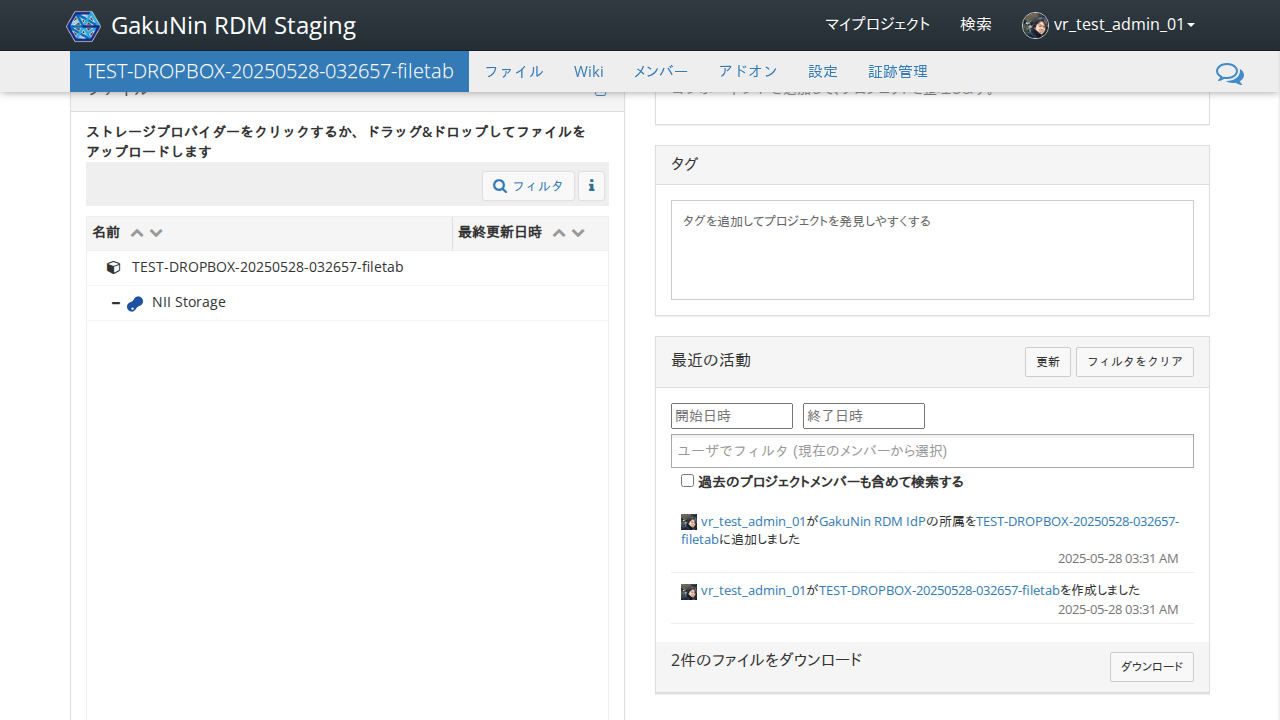

In [27]:
async def _step(page):
    await page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_prefix}-filetab"]').click()        

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, 'NII Storage')).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

Start epoch: 1748403111.026526 seconds


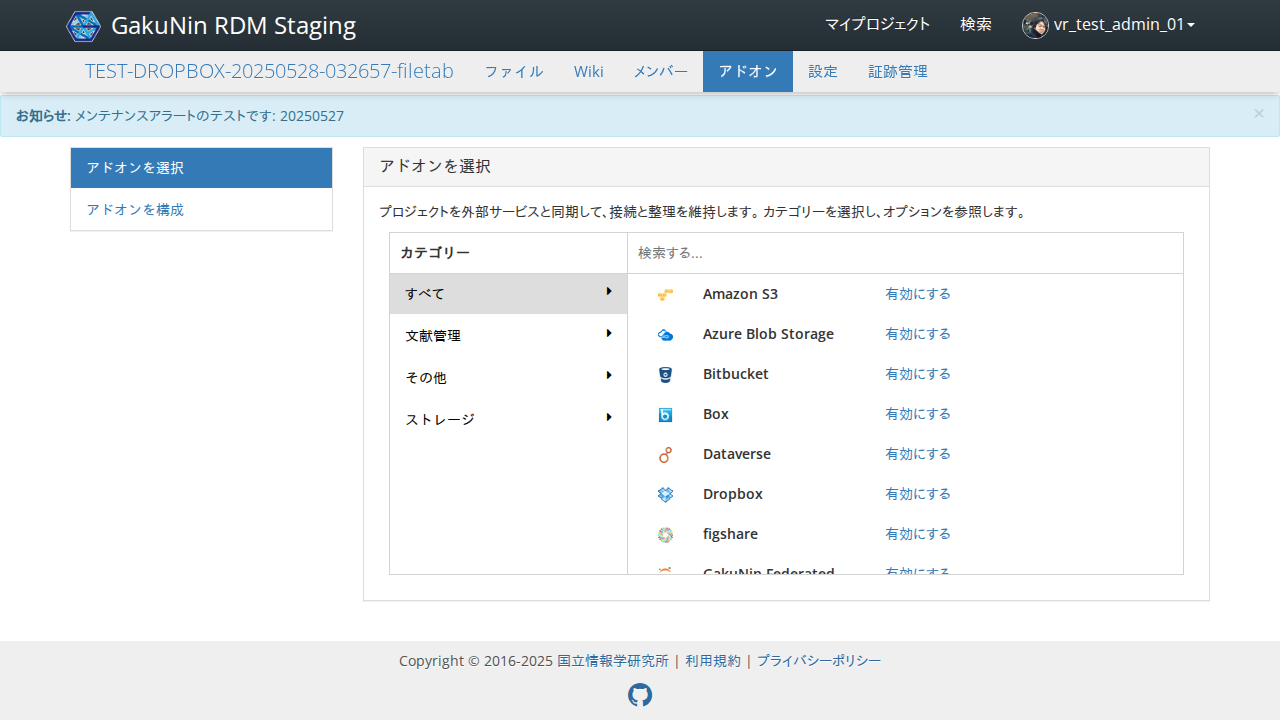

In [28]:
addon_name = target_storage_name

async def _step(page):
    await page.locator('//a[text() = "アドオン"]').click()

    await expect(page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]')).to_be_visible(timeout=10000)

await run_pw(_step)

## 「アドオンを選択」のパネル内対象ストレージの行の「有効にする」をクリックする

Start epoch: 1748403112.9632537 seconds


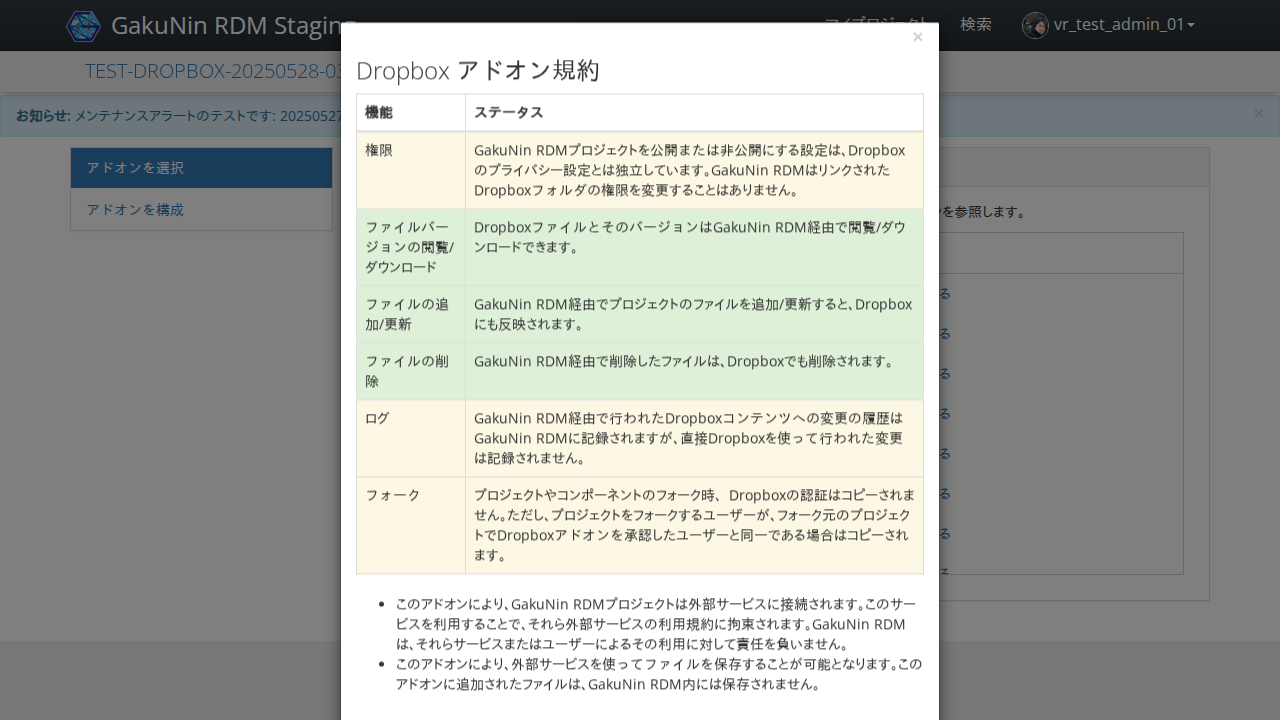

In [29]:
async def _step(page):
    await page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]').click()
    
    await expect(page.locator(f'//button[@data-bb-handler = "confirm"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「確認」をクリックする

Start epoch: 1748403113.5542266 seconds


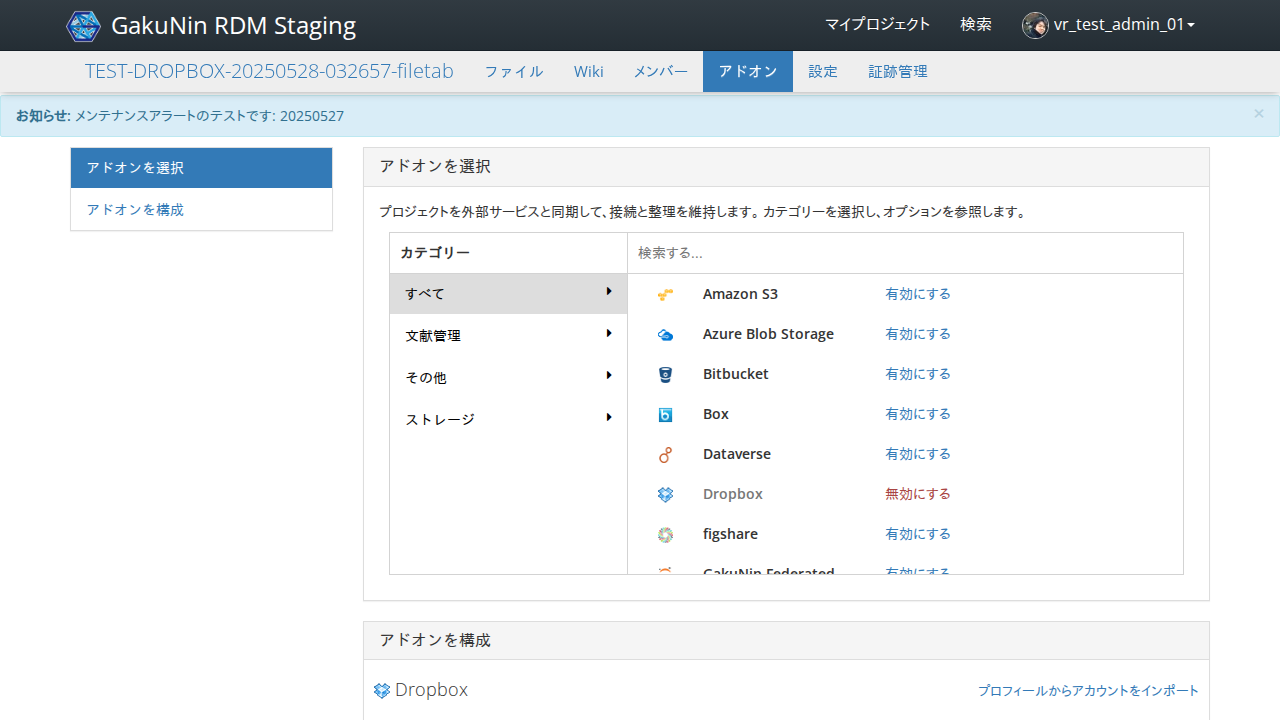

In [30]:
async def _step(page):
    await page.locator(f'//button[@data-bb-handler = "confirm"]').click()
    
    await expect(page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "プロフィールからアカウントをインポート")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「プロフィールからアカウントをインポート」リンクをクリックする

Start epoch: 1748403115.81018 seconds


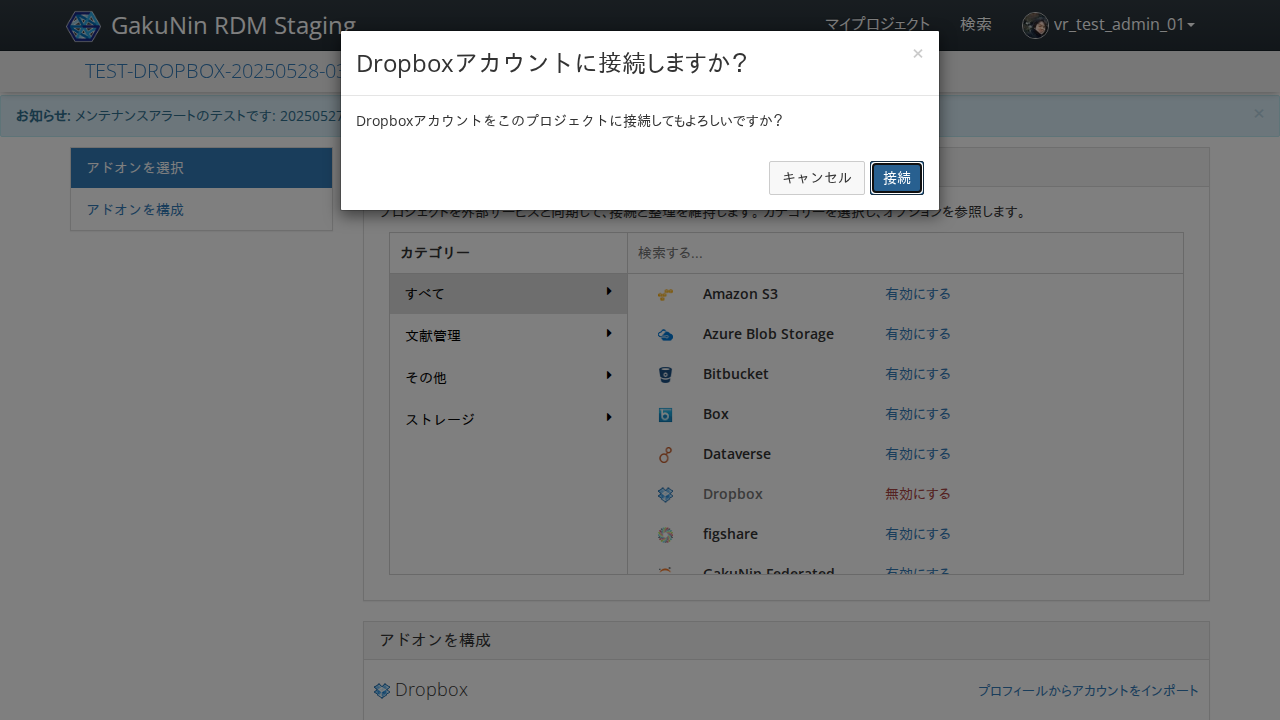

In [31]:
async def _step(page):
    await page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "プロフィールからアカウントをインポート")]').click()

    await expect(page.locator(f'//button[text() = "接続"]')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)

## 「接続」をクリックする

Start epoch: 1748403117.872555 seconds


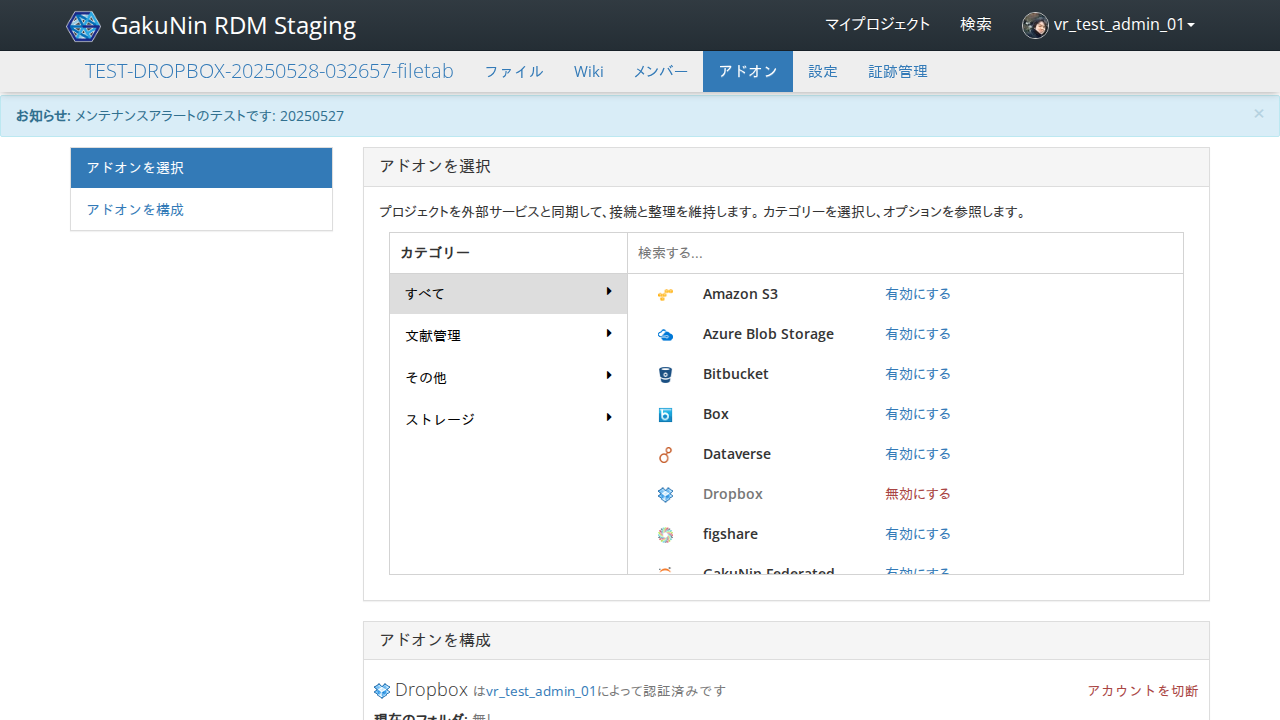

In [32]:
async def _step(page):
    await page.locator(f'//button[text() = "接続"]').click()

    await expect(page.locator(f'//span[text() = "{folder_1}"]/../../..//input[@type = "radio"]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 指定されたフォルダを選択する

Start epoch: 1748403119.950095 seconds


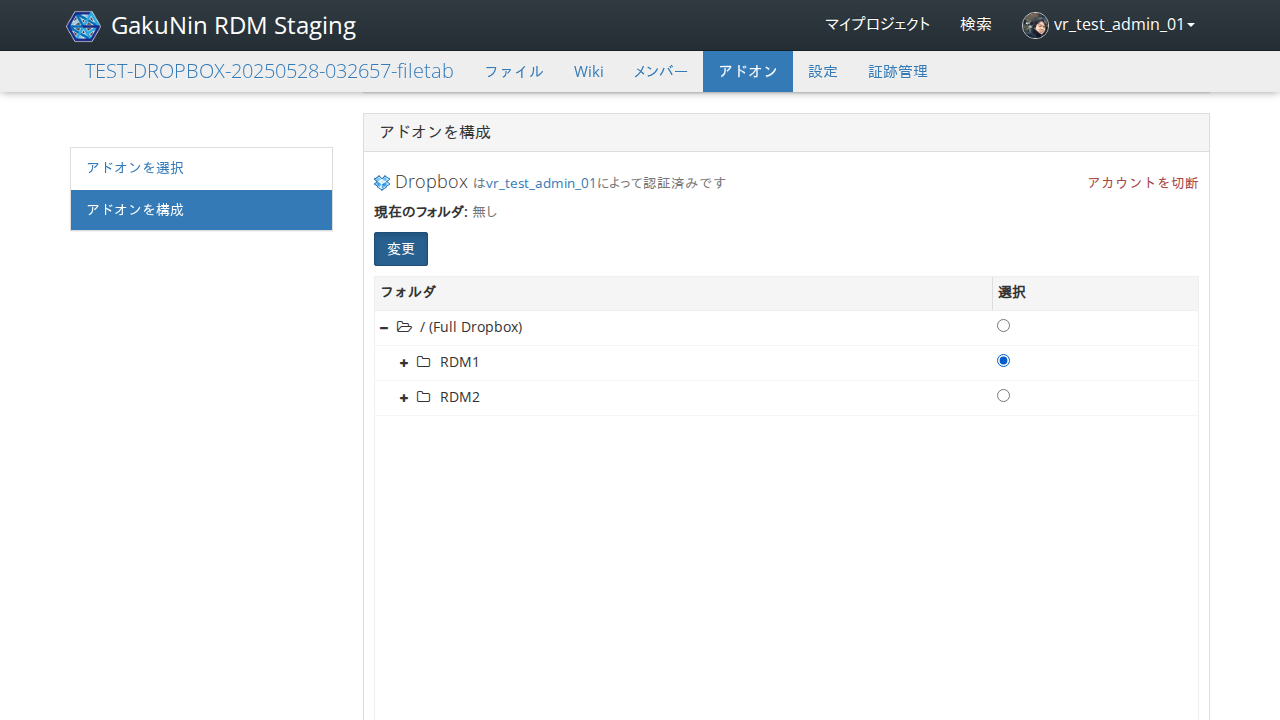

In [33]:
async def _step(page):
    await page.locator(f'//span[text() = "{folder_1}"]/../../..//input[@type = "radio"]').click()

await run_pw(_step)

## 「保存」をクリックする

Start epoch: 1748403120.1404657 seconds


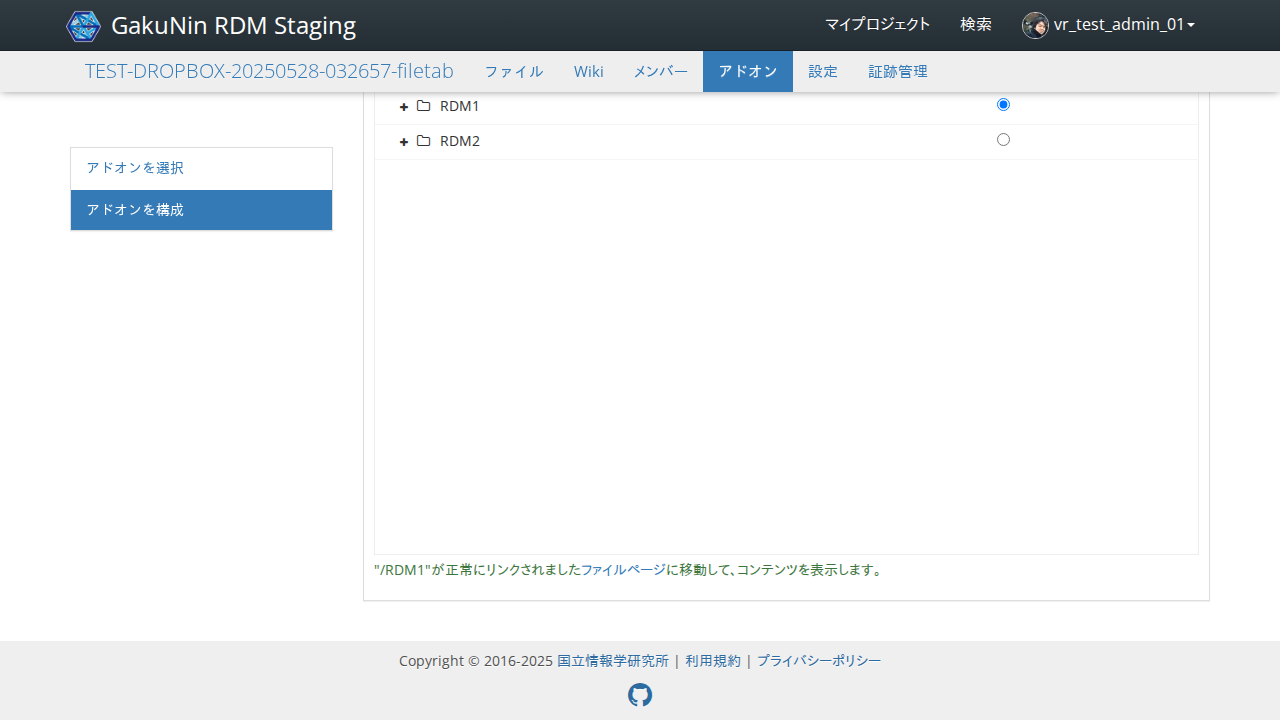

In [34]:
async def _step(page):
    # ここでdelayを入れないと 正常にリンクされました メッセージが表示されない(設定自体はなされるよう - Messageの順序が変わる模様)
    time.sleep(5)
    await page.locator(f'//*[@class = "{target_storage_id}-confirm-selection"]//input[@value = "保存"]').click()
    await expect(page.locator(f'//*[@id = "{target_storage_id}Scope"]/*[contains(@class, "help-block")]//*[contains(text(), "正常にリンクされました")]')).to_be_visible(timeout=30000)

await run_pw(_step)

## 「ファイルページ」リンクをクリックする

Start epoch: 1748403125.706877 seconds


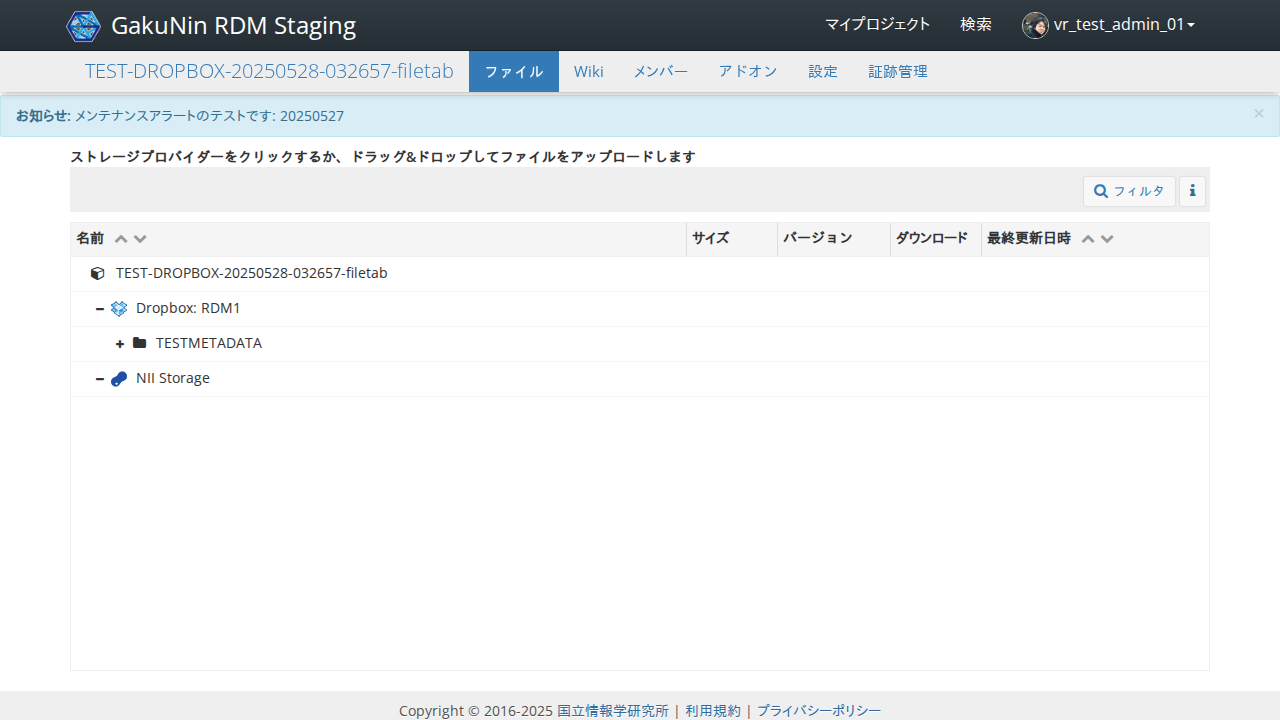

In [35]:
# import scripts.grdm
# importlib.reload(scripts.grdm)

async def _step(page):
    await page.get_by_role("link", name="ファイルページ").click()

    # ストレージが表示されること
    await expect(grdm.get_select_expanded_storage_title_locator(page, target_storage_name)).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await expect(page.locator('//h3[text()="最近の活動"]')).not_to_be_visible()

await run_pw(_step)

## ユーザーメニューから「設定」を選択する


Start epoch: 1748403129.7618303 seconds


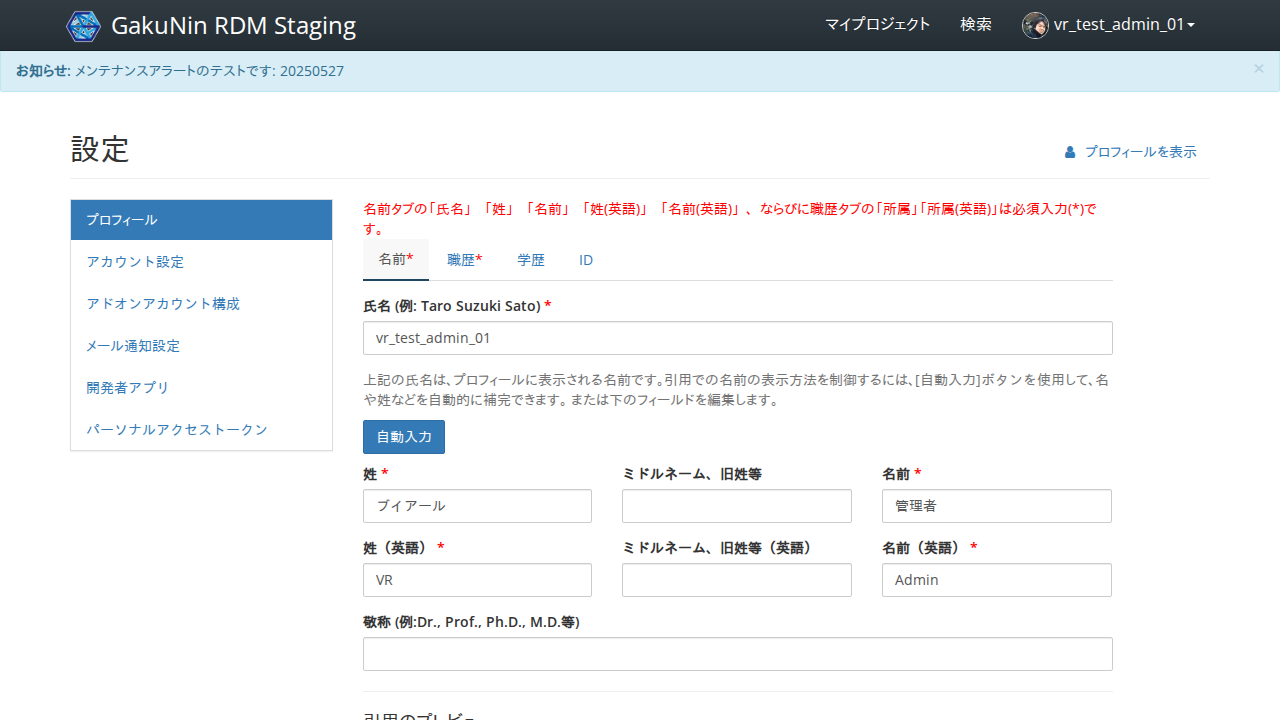

In [36]:
async def _step(page):
    await page.locator(f'//div[@class = "nav-profile-name"]').click()
    await page.locator('//*[@href="/settings/"]').click()

    await expect(page.locator('//*[text() = "アドオンアカウント構成"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「アドオンアカウント構成」を選択する


Start epoch: 1748403130.334717 seconds


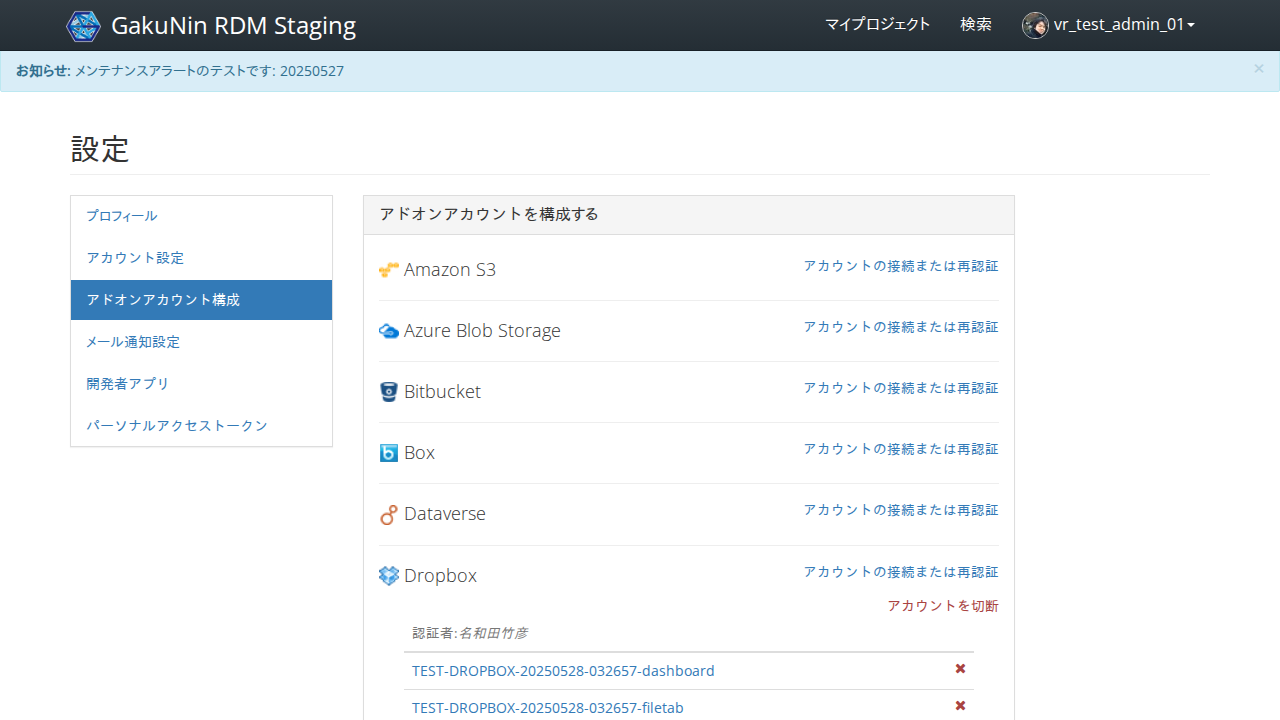

In [37]:
import traceback

async def _step(page):
    await page.locator('//*[text() = "アドオンアカウント構成"]').click()
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../*[text() = "{target_storage_name}"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"]')).to_be_visible(timeout=transition_timeout)

    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "{rdm_project_prefix}-dashboard"]')).to_be_visible()
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "{rdm_project_prefix}-filetab"]')).to_be_visible()

await run_pw(_step)

## 左上 GakuNin RDMロゴをクリックする

Start epoch: 1748403133.6212406 seconds


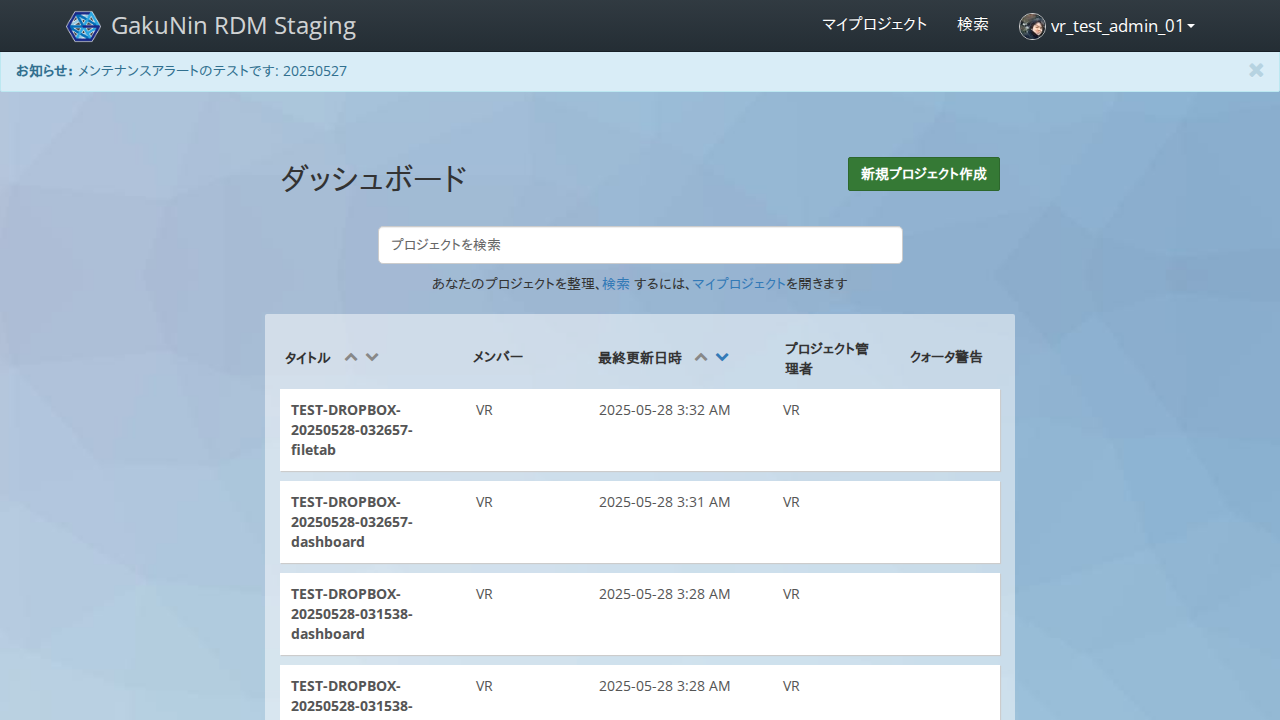

In [38]:
async def _step(page):
    await page.locator('//*[contains(@class, "service-name")]//a').click()
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「TEST-(ストレージID)-YYYYMMDD-HHMMSS-filetab」プロジェクトをクリックする

Start epoch: 1748403136.1213996 seconds


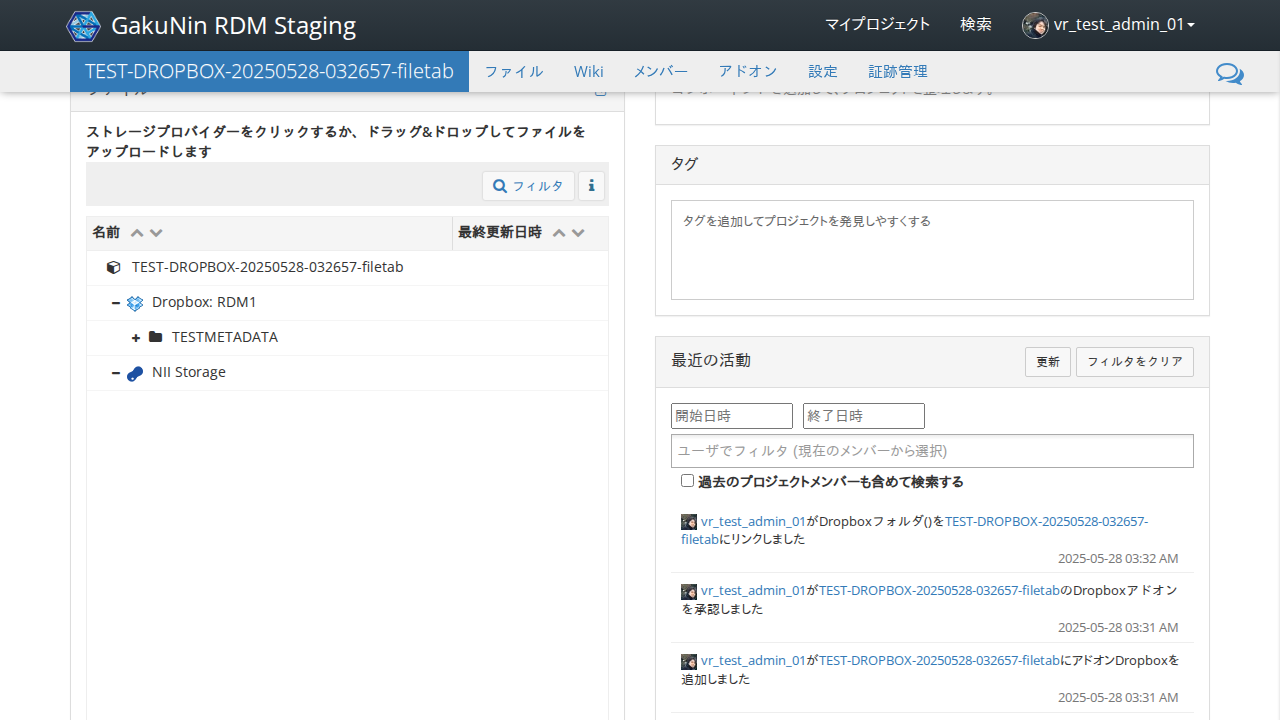

In [39]:
async def _step(page):
    await page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_prefix}-filetab"]').click()        

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, 'NII Storage')).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

Start epoch: 1748403140.2142725 seconds


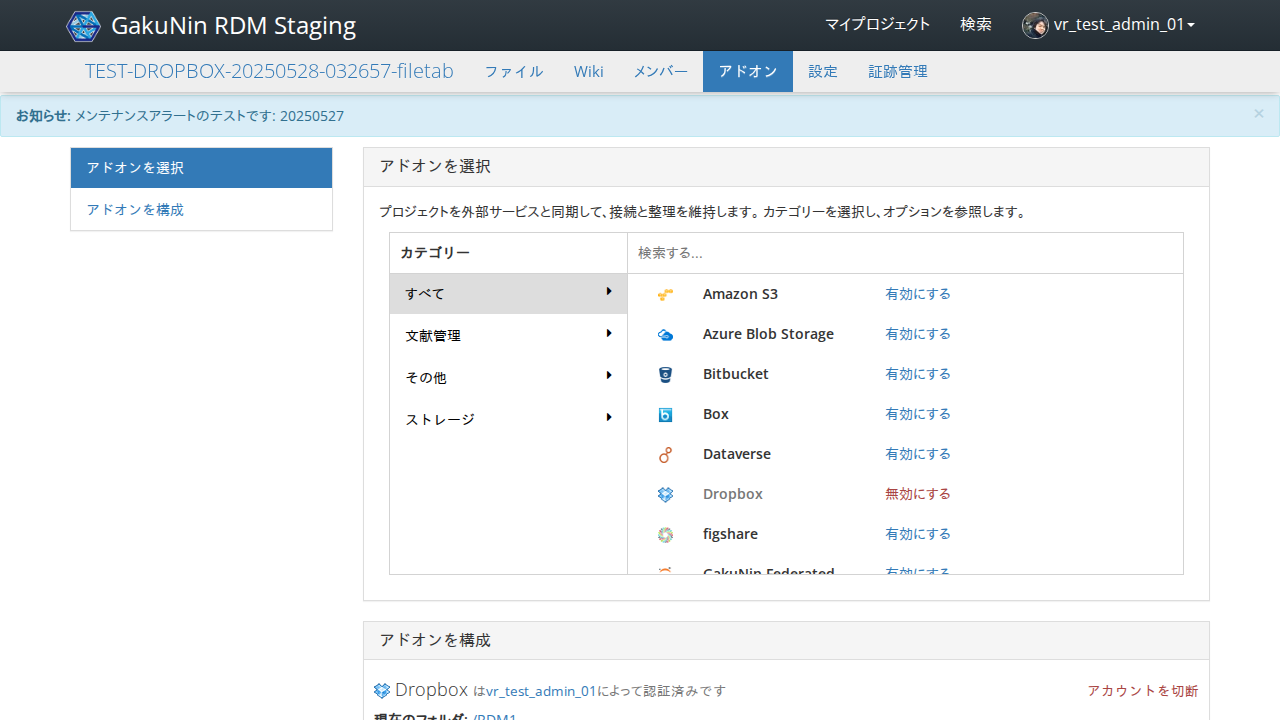

In [40]:
addon_name = target_storage_name

async def _step(page):
    await page.locator('//a[text() = "アドオン"]').click()

    await expect(page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "無効にする"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "アカウントを切断")]')).to_be_visible(timeout=10000)

await run_pw(_step)

## 「アカウントを切断」をクリックする

Start epoch: 1748403143.4749348 seconds


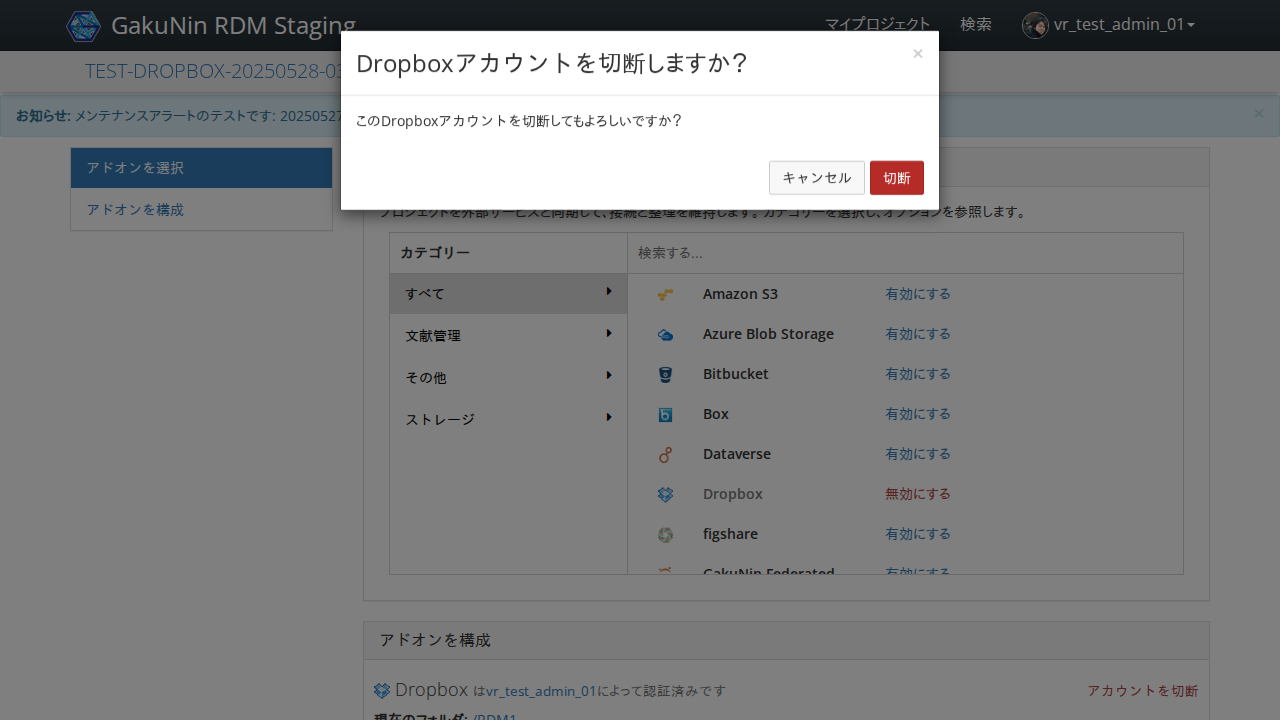

In [41]:
async def _step(page):
    await page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "アカウントを切断")]').click()

    await expect(page.locator('.bootbox-confirm .btn-danger')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「切断」をクリックする

Start epoch: 1748403144.0685594 seconds


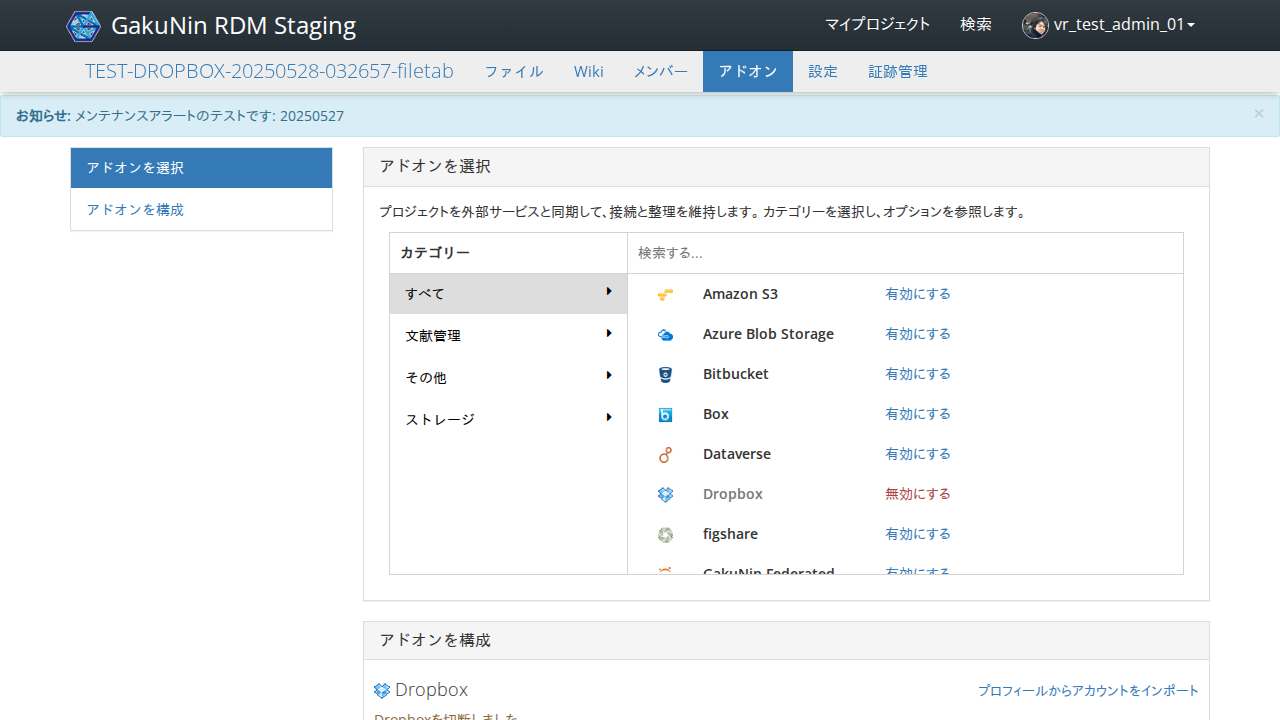

In [42]:
async def _step(page):
    await page.locator('.bootbox-confirm .btn-danger').click()

    await expect(page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "プロフィールからアカウントをインポート")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## ユーザーメニューから「設定」を選択する


Start epoch: 1748403145.1475875 seconds


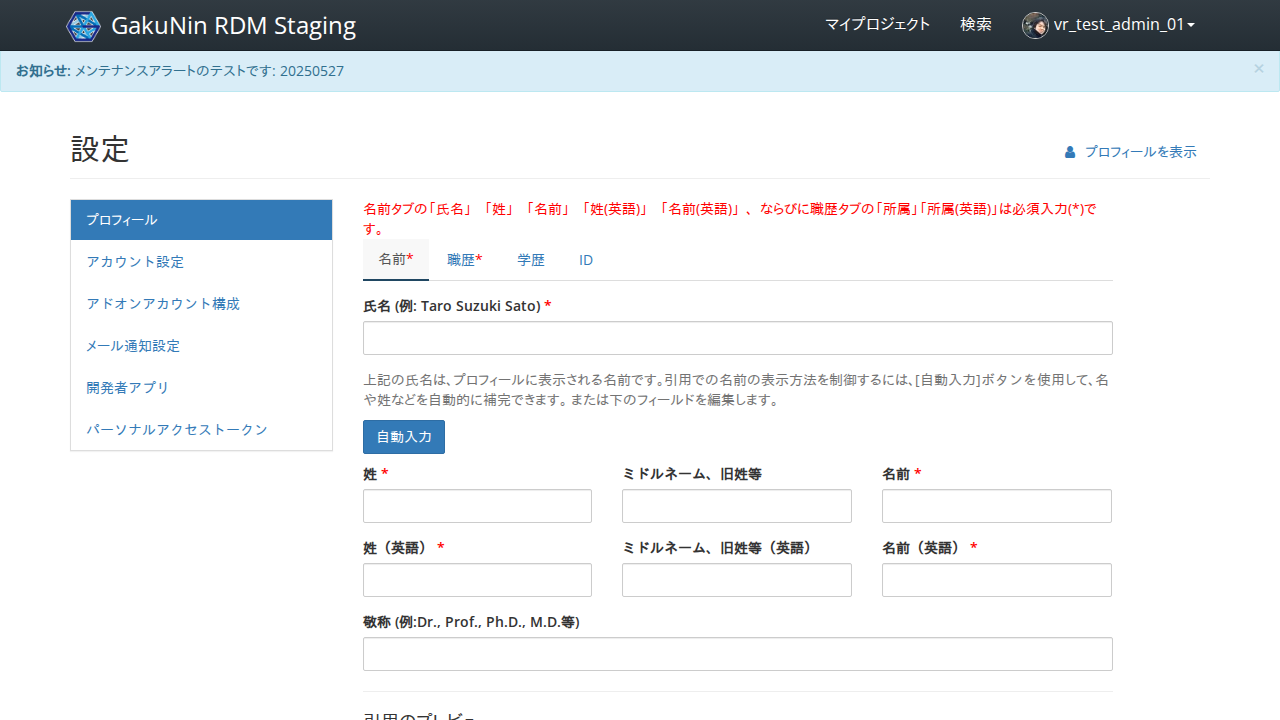

In [43]:
async def _step(page):
    await page.locator(f'//div[@class = "nav-profile-name"]').click()
    await page.locator('//*[@href="/settings/"]').click()

    await expect(page.locator('//*[text() = "アドオンアカウント構成"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「アドオンアカウント構成」を選択する

接続されたプロジェクトリストから、 `-filetab` のものが消えていること。

Start epoch: 1748403145.7060134 seconds


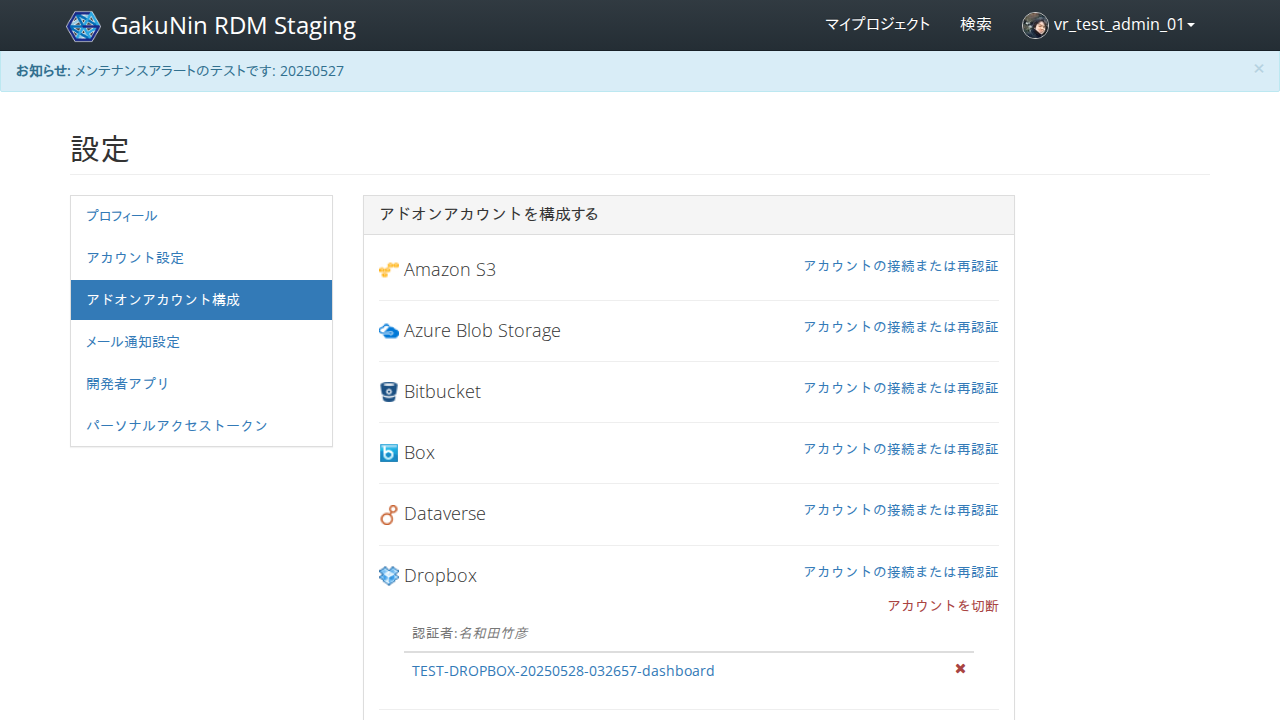

In [44]:
import traceback

async def _step(page):
    await page.locator('//*[text() = "アドオンアカウント構成"]').click()
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../*[text() = "{target_storage_name}"]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"]')).to_be_visible(timeout=transition_timeout)

    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "{rdm_project_prefix}-filetab"]')).to_have_count(0)
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "{rdm_project_prefix}-dashboard"]')).to_be_visible()

await run_pw(_step)

## 対象ストレージの「アカウントの接続または再認証」(Google Driveの場合は「Sign in with Google」)をクリックする


ここからは自動操作できないので、以下のセルの指示に従い、作業を実施する。

1. 指定されたURLを新規のシークレットウィンドウで開く(先の作業とは別のストレージアカウントで認証するため、新規に切り替える必要あり)
2. IdPアカウント1でログインする
1. 「アカウントの接続または再認証」(Google Driveの場合は「Sign in with Google」)リンクをクリックする
2. ストレージアカウント2で認証する


In [45]:
target_url = None
async def _step(page):
    global target_url
    target_url = page.url
await run_pw(_step)
print(target_url)

confirmed = input(prompt='上のURLを開き、セルに指示された作業を実施してください。完了したら、 finished と入力してください。')
assert confirmed.strip().lower() == 'finished'

In [46]:
async def _step(page):
    await page.reload()
    await expect(page.locator(f'//*[@src="/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "アカウントを切断"]')).to_have_count(2, timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)

Start epoch: 1748403305.996363 seconds
Screenshot: result/result-20250528-032518/テスト手順-拡張ストレージ-アカウント設定-Dropbox/last-screenshot.png


AssertionError: Locator expected to have count '2'
Actual value: 1 
Call log:
  - LocatorAssertions.to_have_count with timeout 30000ms
  - waiting for locator("//*[@src=\"/static/addons/dropbox/comicon.png\"]/../..//*[text() = \"アカウントを切断\"]")
    4 × locator resolved to 0 elements
      - unexpected value "0"
    30 × locator resolved to 1 element
       - unexpected value "1"


## 左上 GakuNin RDMロゴをクリックする

In [ ]:
async def _step(page):
    await page.locator('//*[contains(@class, "service-name")]//a').click()
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「TEST-ストレージID-YYYYMMDD-HHMMSS-filetab」プロジェクトをクリックする

In [ ]:
async def _step(page):
    await page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_prefix}-filetab"]').click()        

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, 'NII Storage')).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

In [ ]:
addon_name = target_storage_name

async def _step(page):
    await page.locator('//a[text() = "アドオン"]').click()

    await expect(page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "無効にする"]')).to_be_visible(timeout=10000)

await run_pw(_step)

## 「プロフィールからアカウントをインポート」リンクをクリックする

In [ ]:
async def _step(page):
    await page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "プロフィールからアカウントをインポート")]').click()

    await expect(page.locator(f'//button[text() = "接続"]')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)

## アカウントドロップダウンの2つ目を選択する

In [ ]:
async def _step(page):
    await page.locator('//select[contains(@class, "bootbox-input-select")]').select_option(index=1)

    await expect(page.locator(f'//button[text() = "接続"]')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)

## 「接続」をクリックする

In [ ]:
import traceback

async def _step(page):
    await page.locator(f'//button[text() = "接続"]').click()

    # try:
    await expect(page.locator(f'//span[text() = "{folder_2}"]/../../..//input[@type = "radio"]')).to_be_enabled(timeout=transition_timeout)
    # except:
    #     print('fallback...')
    #     traceback.print_exc()
    #     # 「変更」を押すとリストに現れる場合あり
    #     await page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/../..//*[text() = "変更"]').click()
    #     await expect(page.locator(f'//span[text() = "{folder_2}"]/../../..//input[@type = "radio"]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 指定されたフォルダを選択する

In [ ]:
async def _step(page):
    await page.locator(f'//span[text() = "{folder_2}"]/../../..//input[@type = "radio"]').click()

await run_pw(_step)

## 「保存」をクリックする

In [ ]:
async def _step(page):
    # ここでdelayを入れないと 正常にリンクされました メッセージが表示されない(設定自体はなされるよう)
    time.sleep(5)
    await page.locator(f'//*[@class = "{target_storage_id}-confirm-selection"]//input[@value = "保存"]').click()
    await expect(page.locator(f'//*[@id = "{target_storage_id}Scope"]/*[contains(@class, "help-block")]//*[contains(text(), "正常にリンクされました")]')).to_be_visible(timeout=30000)

await run_pw(_step)

## 「ファイルページ」リンクをクリックする

In [ ]:
# import scripts.grdm
# importlib.reload(scripts.grdm)

async def _step(page):
    await page.get_by_role("link", name="ファイルページ").click()

    # ストレージが表示されること
    await expect(grdm.get_select_expanded_storage_title_locator(page, target_storage_name)).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await expect(page.locator('//h3[text()="最近の活動"]')).not_to_be_visible()

await run_pw(_step)

## 左上 GakuNin RDMロゴをクリックする

In [ ]:
async def _step(page):
    await page.locator('//*[contains(@class, "service-name")]//a').click()
    await expect(page.locator('//*[text() = "プロジェクト管理者"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「TEST-(ストレージID)-YYYYMMDD-HHMMSS-metadata」プロジェクトを作成する

In [ ]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await expect(page.locator('//*[@data-test-create-project-modal-button]')).to_have_count(1)

    await scripts.grdm.ensure_project_exists(page, f'{rdm_project_prefix}-metadata', transition_timeout=transition_timeout)
        
await run_pw(_step)

## ダッシュボードのプロジェクト一覧から作成したプロジェクトをクリックする

In [ ]:
async def _step(page):
    await page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_prefix}-metadata"]').click()        

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, 'NII Storage')).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await page.locator('//h3[text()="最近の活動"]').click()

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「アドオン」をクリックする

In [ ]:
addon_name = target_storage_name

async def _step(page):
    await page.locator('//a[text() = "アドオン"]').click()

    await expect(page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]')).to_be_visible(timeout=10000)

await run_pw(_step)

## 「アドオンを選択」のパネル内対象ストレージの行の「有効にする」をクリックする

In [ ]:
async def _step(page):
    await page.locator(f'//div[@full_name = "{addon_name}"]//descendant::a[text() = "有効にする"]').click()
    
    await expect(page.locator(f'//button[@data-bb-handler = "confirm"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「確認」をクリックする

In [ ]:
async def _step(page):
    await page.locator(f'//button[@data-bb-handler = "confirm"]').click()
    
    await expect(page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "プロフィールからアカウントをインポート")]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## 「プロフィールからアカウントをインポート」リンクをクリックする

In [ ]:
async def _step(page):
    await page.locator(f'//img[@src = "/static/addons/{target_storage_id}/comicon.png"]/..//a[contains(text(), "プロフィールからアカウントをインポート")]').click()

    await expect(page.locator(f'//button[text() = "接続"]')).to_be_enabled(timeout=transition_timeout)
    time.sleep(1)

await run_pw(_step)

## 「接続」をクリックする

In [ ]:
async def _step(page):
    await page.locator(f'//button[text() = "接続"]').click()

    await expect(page.locator(f'//span[text() = "{folder_1}"]/../../..//input[@type = "radio"]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 指定されたフォルダを選択する

In [ ]:
async def _step(page):
    await page.locator(f'//span[text() = "{folder_1}"]/../../..//input[@type = "radio"]').click()

await run_pw(_step)

## 「保存」をクリックする

In [ ]:
async def _step(page):
    # ここでdelayを入れないと 正常にリンクされました メッセージが表示されない(設定自体はなされるよう)
    time.sleep(5)
    await page.locator(f'//*[@class = "{target_storage_id}-confirm-selection"]//input[@value = "保存"]').click()
    await expect(page.locator(f'//*[@id = "{target_storage_id}Scope"]/*[contains(@class, "help-block")]//*[contains(text(), "正常にリンクされました")]')).to_be_visible(timeout=30000)

await run_pw(_step)

## 「ファイルページ」リンクをクリックする

In [ ]:
# import scripts.grdm
# importlib.reload(scripts.grdm)

async def _step(page):
    await page.get_by_role("link", name="ファイルページ").click()

    # ストレージが表示されること
    await expect(grdm.get_select_expanded_storage_title_locator(page, target_storage_name)).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await expect(page.locator('//h3[text()="最近の活動"]')).not_to_be_visible()

await run_pw(_step)

In [ ]:
rdm_project_prefix

終了処理を実施。

In [ ]:
await finish_pw_context()

In [ ]:
!rm -fr {work_dir}